# BITS Pilani — Information Retrieval (S2-25_AIMLZG537)
## Assignment 2: Mini Web Search Engine with Cross-Lingual Retrieval

---

**Section 1 | Group 1**

| Roll No.   | Name                  |
|------------|-----------------------|
| 2025AE05280 | GANESHA V            |
| 2025AE05851 | C V R KARTHIK        |
| 2025AE05138 | ADITYA PRASAD SINGH  |
| 2025AE05129 | ANMOL SINHA          |

---

**Domain:** Medical / Orthopedic Patient Records

<div align="center">

| Component | Implementation |
|---|---|
| Corpus | 2,182 English + 2,182 Hindi patient records |
| Retrieval Model | TF-IDF Vector Space Model + Cosine Similarity |
| Text Mining | Query Expansion (WordNet + Medical Synonym Dictionary) |
| Cross-Lingual | Query Translation (English to Hindi, Hindi to English) |
| Clustering | K-Means (K=6) with PCA visualization |
| UI | Streamlit |
| Evaluation | Precision@10, Recall@10, MAP over 24 queries |

</div>

# Imports & Enviornment Setup

In [1]:
# ==========================================
# INSTALLATION & IMPORTS
# ==========================================
# Application and Serialization
import pandas as pd
import numpy as np
import re, random
import string, pip
import pickle, os
from collections import Counter,defaultdict
import textwrap

# Graphs and Plotting Charts
from matplotlib import pyplot as plt, cm
import seaborn as sns

# Vector Space Model & Clustering
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

# NLP Libraries for English
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet as wn
# NLP Libraries for Hindi (Indic NLP)
from indicnlp.tokenize import indic_tokenize
from indicnlp.normalize.indic_normalize import DevanagariNormalizer,GurmukhiNormalizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
# Cross-Lingual Translation
from deep_translator import GoogleTranslator
from sentence_transformers import SentenceTransformer, util
import torch

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

[nltk_data] Downloading package punkt to /home/coder/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/coder/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/coder/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/coder/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/coder/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
/home/coder/.local/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


All libraries imported successfully.


In [2]:
# Language-specific stopwords
ENGLISH_STOPWORDS = set(stopwords.words('english'))
HINDI_STOPWORDS = set([
    'के', 'का', 'एक', 'में', 'की', 'है', 'यह', 'और', 'से', 'हैं', 'को', 'पर', 'इस',
    'होता', 'कि', 'जो', 'कर', 'मे', 'गया', 'करने', 'किया', 'लिये', 'अपने', 'ने',
    'बनी', 'नहीं', 'तो', 'ही', 'या', 'एवं', 'दिया', 'हो', 'इसका', 'था', 'द्वारा',
    'हुआ', 'तक', 'साथ', 'गये', 'थे', 'दो', 'वे', 'होते', 'थी', 'हुई', 'ई', 'जा',
    'सकता', 'होने', 'गई', 'अत', 'अपना', 'इसमें', 'सकते', 'देखा', 'चलते', 'आदि',
    'लेकर', 'बड़ा', 'जाता', 'दोस्त'
])
PUNJABI_STOPWORDS = {
'ਦੇ','ਦੀ','ਦਾ','ਵਿੱਚ','ਨੂੰ','ਕਿ','ਅਤੇ','ਹੈ','ਹਨ','ਇਸ','ਦੀਆਂ','ਨਾਲ','ਇੱਕ','ਤੇ','ਇਹ','ਉਹ','ਤੋਂ',
}
stemmer_en    = PorterStemmer()
normalizer_hi = DevanagariNormalizer()
normalizer_pb = GurmukhiNormalizer()
print('All imports successful. ✓')

All imports successful. ✓


# Dataset (Section- 3)

In [3]:
# ================================================================
# CORPUS CONSTRUCTION  (CSV + fallback synthetic)
# ================================================================
# https://www.kaggle.com/code/kajolagga/notebook8e616322de/notebook
# Paths to your files – adjust if needed
en_path = 'updated_result_with_BERT.csv'
hi_path = 'updated_result_with_AI_HINDI.csv'
pb_path = 'updated_result_with_AI_PUNJABI.csv'
try:
    df_en = pd.read_csv(en_path)
    df_hi = pd.read_csv(hi_path)
    df_pb = pd.read_csv(pb_path)
    print(f"Loaded: English {len(df_en)} rows, Hindi {len(df_hi)} rows, Punjabi {len(df_pb)} rows")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the files are in the notebook directory.")
# Define the columns to combine
text_cols = ['Diagnosis', 'symptoms', 'Patient History']
def create_content(row):
    parts = [str(row[col]).strip() for col in text_cols if pd.notna(row[col]) and pd.notna(row.get(col, "")) and str(row.get(col, "")).strip()]
    return " ".join(parts)
 # Synthetic fallback corpus_list
def build_synthetic_corpus():
    rng = np.random.default_rng(42)

    # Alternative data for generic queries if dataset unavailable or unable to be fetched/loaded
    EN = {
        "Hip-related disorders": [
            "Hip pain with restricted range of motion due to avascular necrosis of the femoral head.",
            "Patient presents with groin pain and limping caused by osteoarthritis of the hip joint.",
            "Total hip replacement indicated for severe hip dysplasia and cartilage degeneration.",
            "Acetabular labral tear causing clicking and discomfort during walking.",
            "Bilateral hip pain with morning stiffness consistent with ankylosing spondylitis.",
        ],
        "Knee-related disorders": [
            "Anterior cruciate ligament tear with joint effusion following sports injury.",
            "Medial meniscus derangement presenting with locking and swelling of the knee.",
            "Patellofemoral pain syndrome with chondromalacia patellae in young athlete.",
            "Osteoarthritis of the knee causing varus deformity and bone-on-bone contact.",
            "Popliteal cyst detected on MRI with knee flexion limitation.",
        ],
        "Bone-related disorders": [
            "Fracture of the femoral neck requiring internal fixation with cannulated screws.",
            "Osteoporotic vertebral compression fracture treated with bisphosphonate therapy.",
            "Osteomyelitis of the tibia with elevated CRP and bone marrow edema on MRI.",
            "Pathological fracture secondary to bone metastasis from primary lung cancer.",
            "Stress fracture of the metatarsal due to repetitive loading in marathon runner.",
        ],
        "Musculoskeletal disorders": [
            "Rheumatoid arthritis with symmetric joint swelling, warmth, and elevated RF.",
            "Fibromyalgia with widespread muscle pain, fatigue, and tender points.",
            "Polymyalgia rheumatica presenting with shoulder girdle pain in elderly female.",
            "Reactive arthritis following urinary tract infection with oligoarticular involvement.",
            "Muscle weakness and elevated CK consistent with inflammatory myopathy.",
        ],
        "Spine-related disorders": [
            "L4-L5 disc herniation with radiculopathy causing sciatica down the left leg.",
            "Cervical myelopathy due to multilevel spondylosis with upper limb weakness.",
            "Lumbar spinal stenosis with neurogenic claudication and bilateral leg pain.",
            "Scoliosis with Cobb angle 40 degrees requiring surgical correction.",
            "Sacroiliac joint dysfunction causing low back pain with referred gluteal pain.",
        ],
        "Other": [
            "Complex regional pain syndrome type I following distal radius fracture.",
            "Gout with uric acid crystals in synovial fluid of the first metatarsophalangeal joint.",
            "Paget's disease of bone with elevated alkaline phosphatase and bone remodelling.",
            "Dupuytren's contracture of the ring and little finger in a middle-aged male.",
            "Carpal tunnel syndrome with nocturnal paraesthesia and positive Tinel sign.",
        ],
    }
    HI = {
        "Hip-related disorders": [
            "कूल्हे में तीव्र दर्द और चलने में कठिनाई, फीमर हेड की एवैस्कुलर नेक्रोसिस।",
            "कूल्हे के जोड़ में सूजन और जकड़न, ऑस्टियोआर्थराइटिस के लक्षण।",
            "हिप डिसप्लेसिया के कारण टोटल हिप रिप्लेसमेंट की आवश्यकता।",
            "कमर दर्द और लंगड़ाहट, एसिटैबुलर लैब्रल टियर।",
        ],
        "Knee-related disorders": [
            "घुटने में सूजन और ACL टियर के बाद अस्थिरता।",
            "मेडियल मेनिस्कस की चोट से घुटने में लॉकिंग और दर्द।",
            "घुटने की ऑस्टियोआर्थराइटिस से हड्डी-पर-हड्डी घर्षण।",
        ],
        "Bone-related disorders": [
            "फीमर गर्दन का फ्रैक्चर, कैनुलेटेड स्क्रू से फिक्सेशन।",
            "ऑस्टियोपोरोसिस के कारण रीढ़ की हड्डी में कम्प्रेशन फ्रैक्चर।",
            "टिबिया में ऑस्टियोमाइलाइटिस, MRI पर बोन मैरो एडिमा।",
        ],
        "Musculoskeletal disorders": [
            "रूमेटोइड आर्थराइटिस, सममित जोड़ों की सूजन और RF पॉजिटिव।",
            "फाइब्रोमायल्जिया, व्यापक मांसपेशी दर्द और थकान।",
            "मांसपेशियों की कमजोरी और CK बढ़ा हुआ।",
        ],
        "Spine-related disorders": [
            "L4-L5 डिस्क हर्नियेशन, बाएं पैर में साइटिका।",
            "लम्बर स्पाइनल स्टेनोसिस, न्यूरोजेनिक क्लॉडिकेशन।",
        ],
        "Other": [
            "गाउट, पहले MTP जोड़ में यूरिक एसिड क्रिस्टल।",
            "CRPS टाइप I, दूरस्थ रेडियस फ्रैक्चर के बाद।",
        ],
    }
    PB = {
        "Hip-related disorders":  ["ਕੁੱਲ੍ਹੇ ਵਿੱਚ ਦਰਦ ਅਤੇ ਤੁਰਨ ਵਿੱਚ ਮੁਸ਼ਕਲ।", "ਕੁੱਲ੍ਹੇ ਦੇ ਜੋੜ ਵਿੱਚ ਸੋਜ।"],
        "Knee-related disorders": ["ਗੋਡੇ ਵਿੱਚ ਸੋਜ ਅਤੇ ACL ਟੀਅਰ।", "ਗੋਡੇ ਵਿੱਚ ਲੌਕਿੰਗ।"],
        "Bone-related disorders": ["ਫੀਮਰ ਦੀ ਗਰਦਨ ਦਾ ਫ੍ਰੈਕਚਰ।", "ਔਸਟੀਓਪੋਰੋਸਿਸ ਕਾਰਨ ਕੰਪਰੈਸ਼ਨ ਫ੍ਰੈਕਚਰ।"],
        "Musculoskeletal disorders": ["ਰਿਊਮੈਟੋਇਡ ਆਰਥਰਾਈਟਿਸ, ਜੋੜਾਂ ਵਿੱਚ ਸੋਜ।"],
        "Spine-related disorders": ["L4-L5 ਡਿਸਕ ਹਰਨੀਏਸ਼ਨ, ਖੱਬੀ ਲੱਤ ਵਿੱਚ ਦਰਦ।"],
        "Other":                   ["ਗਾਊਟ, ਪਹਿਲੇ MTP ਜੋੜ ਵਿੱਚ ਯੂਰਿਕ ਐਸਿਡ।"],
    }
    
    rows, pid = [], 1
    for cat, tmpl in EN.items():
        for i in range(25):
            rows.append({"doc_id":f"EN_{pid:04d}","original_text":tmpl[i%len(tmpl)],"language":"en","category":cat})
            pid += 1
    for cat, tmpl in HI.items():
        for i in range(8):
            rows.append({"doc_id":f"HI_{pid:04d}","original_text":tmpl[i%len(tmpl)],"language":"hi","category":cat})
            pid += 1
    for cat, tmpl in PB.items():
        for t in tmpl:
            rows.append({"doc_id":f"PB_{pid:04d}","original_text":t,"language":"pb","category":cat})
            pid += 1
    return pd.DataFrame(rows)

# Build corpus_list: English + Hindi + Punjabi (Punjabi increases non-English proportion)
corpus_list = []
# English documents
for idx, row in df_en.iterrows():
    corpus_list.append({
        'doc_id': f"EN_{row['patient_id']}_{idx}",
        'original_text': create_content(row),
        'language': 'en',
        'category': row['Diagnosis Category']
    })
# Hindi documents
for idx, row in df_hi.iterrows():
    corpus_list.append({
        'doc_id': f"HI_{row['patient_id']}_{idx}",
        'original_text': create_content(row),
        'language': 'hi',
        'category': row['Diagnosis Category']
    })
# Punjabi documents
for idx, row in df_pb.iterrows():
    corpus_list.append({
        'doc_id': f"PB_{row['patient_id']}_{idx}",
        'original_text': create_content(row),
        'language': 'pa',
        'category': row['Diagnosis Category']
    })
corpus_df = pd.DataFrame(corpus_list)
corpus_df['original_text'] = corpus_df['original_text'].fillna('')
print(f"\
Total documents: {len(corpus_df)}")
print("Language distribution (% - Percentage):")
print(corpus_df['language'].value_counts(normalize=True) * 100)
corpus_df.head()

Loaded: English 2182 rows, Hindi 2182 rows, Punjabi 2182 rows
Total documents: 6546
Language distribution (% - Percentage):
language
en    33.333333
hi    33.333333
pa    33.333333
Name: proportion, dtype: float64


,doc_id,original_text,language,category
0,EN_1049_0,Avascular Necrosis of the Left Hip Pain in hip...,en,Hip-related disorders
1,EN_7622_1,Avascular Necrosis of the Left Hip Discomfort ...,en,Hip-related disorders
2,EN_8063_2,Avascular Necrosis of the Left Hip Pain in hip...,en,Hip-related disorders
3,EN_9737_3,Avascular Necrosis of Bilateral Hips Pain in h...,en,Hip-related disorders
4,EN_4318_4,Avascular Necrosis of Bilateral Hips Aching in...,en,Hip-related disorders


In [4]:
# Each document = concatenation of key clinical fields
FIELDS = ['Patient History', 'symptoms', 'treatment', 'Diagnosis', 'Remarks']
stemmer = PorterStemmer()
en_stopwords = set(stopwords.words('english'))
# Add domain-specific stopwords that add no retrieval value
CUSTOM_STOPWORDS = {
    'patient', 'history', 'treatment', 'diagnosis', 'doctor',
    'medical', 'hospital', 'week', 'weeks', 'month', 'months',
    'also', 'noted', 'shown', 'reported', 'indicates', 'confirmed'
}
en_stopwords.update(CUSTOM_STOPWORDS)
def preprocess_english(text):
    """
    Full preprocessing pipeline for English text:
    1. Lowercase
    2. Remove punctuation & digits
    3. Tokenize
    4. Remove stopwords
    5. Stem
    Returns: list of processed tokens
    """
    if not isinstance(text, str):
        return []
    # Lowercase
    text = text.lower()
    # Remove punctuation and digits
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and single-char tokens
    tokens = [t for t in tokens if t not in en_stopwords and len(t) > 1]
    # Stem
    tokens = [stemmer.stem(t) for t in tokens]
    
    return tokens
def build_doc_text(df, fields=FIELDS):
    """Concatenate selected fields into a single searchable document string."""
    return df[fields].fillna('').agg(' '.join, axis=1)
df_en['doc_text'] = build_doc_text(df_en)
df_hi['doc_text'] = build_doc_text(df_hi)

# Apply to English corpus
df_en['tokens'] = df_en['doc_text'].apply(preprocess_english)
df_en['processed_text'] = df_en['tokens'].apply(lambda tokens: ' '.join(tokens))

# Verify
print("Sample tokens (doc 0):")
print(df_en['tokens'].iloc[0])
print(f"\nAvg tokens per document: {df_en['tokens'].apply(len).mean():.1f}")
print(f"Min tokens: {df_en['tokens'].apply(len).min()}")
print(f"Max tokens: {df_en['tokens'].apply(len).max()}")
# Flatten all tokens to build vocabulary
all_tokens = [token for doc_tokens in df_en['tokens'] for token in doc_tokens]
token_freq = Counter(all_tokens)
print(f"Total tokens (with repeats) : {len(all_tokens):,}")
print(f"Unique vocabulary size      : {len(token_freq):,}")
print(f"\nTop 30 most frequent tokens:")
print(token_freq.most_common(30))
# Quick peek
df_en[['patient_id', 'Diagnosis', 'symptoms', 'treatment', 'Patient History', 'Diagnosis Category','Remarks']].head(5)

Sample tokens (doc 0):
['complain', 'persist', 'pain', 'left', 'hip', 'especi', 'long', 'walk', 'nsaid', 'provid', 'partial', 'relief', 'pain', 'hip', 'area', 'restrict', 'hip', 'movement', 'challeng', 'walk', 'decreas', 'hip', 'flexibl', 'weight', 'manag', 'strategi', 'avascular', 'necrosi', 'left', 'hip', 'evalu', 'need']

Avg tokens per document: 23.9
Min tokens: 14
Max tokens: 35
Total tokens (with repeats) : 52,107
Unique vocabulary size      : 635

Top 30 most frequent tokens:
[('hip', 4569), ('pain', 2067), ('movement', 1300), ('avascular', 1298), ('necrosi', 1298), ('weight', 1227), ('limit', 1223), ('stiff', 1213), ('joint', 1123), ('bone', 970), ('reduc', 959), ('area', 830), ('mobil', 801), ('manag', 780), ('bilater', 739), ('routin', 702), ('discomfort', 692), ('ach', 690), ('walk', 590), ('restrict', 583), ('difficulti', 567), ('physic', 567), ('medic', 546), ('therapi', 534), ('decreas', 525), ('symptom', 523), ('fractur', 498), ('motion', 464), ('rang', 461), ('left', 45

,patient_id,Diagnosis,symptoms,treatment,Patient History,Diagnosis Category,Remarks
0,1049,Avascular Necrosis of the Left Hip,"Pain in hip area, Restricted hip movement, Cha...",Weight management strategies,The patient complains of persistent pain in th...,Hip-related disorders,Further evaluation needed.
1,7622,Avascular Necrosis of the Left Hip,"Discomfort in groin, Limited mobility, Challen...",Weight management strategies,MRI confirmed avascular necrosis of the left h...,Hip-related disorders,Routine check-up required.
2,8063,Avascular Necrosis of the Left Hip,"Pain in hip area, Limited mobility, Difficulty...",Pain management with medications,Gradual onset of left hip pain with restricted...,Hip-related disorders,Further evaluation needed.
3,9737,Avascular Necrosis of Bilateral Hips,"Pain in hip area, Limited mobility, Trouble wi...",Pain management with medications,MRI indicates avascular necrosis in both hips....,Hip-related disorders,Routine check-up required.
4,4318,Avascular Necrosis of Bilateral Hips,"Aching in buttocks, Hip stiffness, Difficulty ...",Physical therapy and exercise routines,"The patient reports bilateral hip pain, worsen...",Hip-related disorders,Patient is stable.


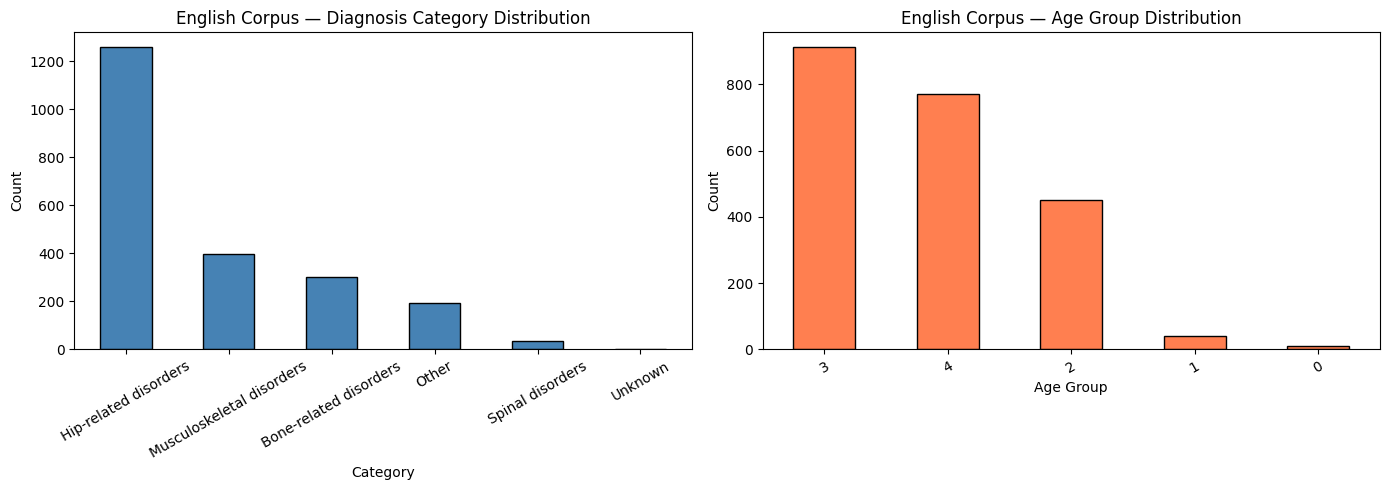

In [5]:
#Category distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_en['Diagnosis Category'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('English Corpus — Diagnosis Category Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
df_en['age_group'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('English Corpus — Age Group Distribution')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Preprocessing(Section-4.1)

## Tokenizaation, Stop Words Removal, Stemming/Lemmatization

In [6]:
stemmer = PorterStemmer()
def preprocess_english(text, stem=True):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha() and w not in ENGLISH_STOPWORDS]
    if stem:
        tokens = [stemmer.stem(w) for w in tokens]
    return " ".join(tokens)
def preprocess_hindi(text, stem=False):
    normalizer_hi = DevanagariNormalizer()
    text = normalizer_hi.normalize(text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    tokens = indic_tokenize.trivial_tokenize(text, lang='hi')
    tokens = [w for w in tokens if w not in HINDI_STOPWORDS]
    return " ".join(tokens)
def preprocess_punjabi(text):
    normalizer_pb = GurmukhiNormalizer()
    text = normalizer_pb.normalize(text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text.lower())
    tokens = indic_tokenize.trivial_tokenize(text, lang='pa')
    tokens = [w for w in tokens if w not in PUNJABI_STOPWORDS]
    return " ".join(tokens)
def preprocess_row(row, stem=True):
    text = row['original_text']
    lang = row['language']
    if lang == 'en':
        return preprocess_english(text, stem=stem)
    elif lang == 'hi':
        return preprocess_hindi(text, stem=stem)
    else:
        return preprocess_punjabi(text)
def preprocess_text(text, lang):
    if not text or pd.isna(text): return ''
    if lang == 'en': return preprocess_english(str(text))
    if lang == 'hi': return preprocess_hindi(str(text))
    if lang == 'pb': return preprocess_punjabi(str(text))
    return str(text)
print('Preprocessing corpus …')
corpus_df['processed_text'] = corpus_df.apply(
    lambda r: preprocess_text(r['original_text'], r['language']), axis=1)
print('Done.')
print('\nSample EN  RAW :', corpus_df[corpus_df.language=='en'].iloc[0]['original_text'][:90])
print('Sample EN PROC :', corpus_df[corpus_df.language=='en'].iloc[0]['processed_text'][:90])
print('Sample HI  RAW :', corpus_df[corpus_df.language=='hi'].iloc[0]['original_text'][:70])
print('Sample HI PROC :', corpus_df[corpus_df.language=='hi'].iloc[0]['processed_text'][:70])
print('Sample PB RAW :', corpus_df[corpus_df.language=='pa'].iloc[0]['original_text'][:70])
print('Sample PB PROC :', corpus_df[corpus_df.language=='pa'].iloc[0]['processed_text'][:70])
print("\nPreprocessing documents (this may take a minute)...")
corpus_df['processed_text'] = corpus_df.apply(lambda row: preprocess_row(row, stem=True), axis=1)
corpus_df['clean_text'] = corpus_df.apply(lambda row: preprocess_row(row, stem=False), axis=1)
print("Preprocessing complete.")
# Sample
print("\
Original:", corpus_df.iloc[0]['original_text'][:100])
print("Processed:", corpus_df.iloc[0]['processed_text'][:100])

Preprocessing corpus …
Done.

Sample EN  RAW : Avascular Necrosis of the Left Hip Pain in hip area, Restricted hip movement, Challenges i
Sample EN PROC : avascular necrosi left hip pain hip area restrict hip movement challeng walk decreas hip f
Sample HI  RAW : बाएं कूल्हे का अस्वास्कुलर नेक्रोसिस कूल्हे के क्षेत्र में दर्द, कूल्ह
Sample HI PROC : बाएं कूल्हे अस्वास्कुलर नेक्रोसिस कूल्हे क्षेत्र दर्द कूल्हे गति प्रति
Sample PB RAW : ਖੱਬੀ ਕਮਰ ਦਾ ਅਵੈਸਕੁਲਰ ਨੈਕਰੋਸਿਸ ਕਮਰ ਦੇ ਖੇਤਰ ਵਿੱਚ ਦਰਦ, ਕਮਰ ਦੀ ਸੀਮਤ ਅੰਦੋਲਨ
Sample PB PROC : ਖੱਬੀ ਕਮਰ ਦਾ ਅਵੈਸਕੁਲਰ ਨੈਕਰੋਸਿਸ ਕਮਰ ਦੇ ਖੇਤਰ ਵਿੱਚ ਦਰਦ, ਕਮਰ ਦੀ ਸੀਮਤ ਅੰਦੋਲਨ

Preprocessing documents (this may take a minute)...
Preprocessing complete.
Original: Avascular Necrosis of the Left Hip Pain in hip area, Restricted hip movement, Challenges in walking,
Processed: avascular necrosi left hip pain hip area restrict hip movement challeng walk decreas hip flexibl pat


## Inverted Index Construction

In [7]:
# ================================================================
# INVERTED INDEX
# Maps every unique term ---> sorted list of all doc_ids containing it.
# (Original draft only covered first 500 terms — fixed to cover ALL)
# ================================================================


def build_inverted_index(df, token_col='tokens', id_col='patient_id'):
    """
    Build an inverted index:
    { term -> { doc_id -> term_frequency } }
    """
    index = defaultdict(lambda: defaultdict(int))
    
    for _, row in df.iterrows():
        doc_id = row[id_col]
        for token in row[token_col]:
            index[token][doc_id] += 1
    
    # Convert to regular dict for clarity
    index = {term: dict(postings) for term, postings in index.items()}
    return index
    
inverted_index = build_inverted_index(df_en)
print(f"Inverted index size: {len(inverted_index):,} unique terms")
print(f"\nRaw Sample — postings for 'hip'  : {list(inverted_index.get('hip', {}).items())[:5]}")
print(f"Raw Sample — postings for 'pain' : {list(inverted_index.get('pain', {}).items())[:5]}")
print(f"Raw Sample — postings for 'fract': {list(inverted_index.get('fract', {}).items())[:5]}")

inverted_index = defaultdict(list)
for _, row in corpus_df.iterrows():
    for token in row['processed_text'].split():
        if token:
            inverted_index[token].append(row['doc_id'])
# Deduplicate (a word can appear multiple times in same doc)
inverted_index = {t: sorted(set(d)) for t, d in inverted_index.items()}
print(f'Inverted index: {len(inverted_index):,} unique terms across {len(corpus_df)} documents')
sample_terms = ['hip', 'fracture', 'arth', 'दर्द', 'ਦਰਦ']
print('\nSample entries:')
for t in sample_terms:
    d = inverted_index.get(t, [])
    print(f"  '{t}' ---> {d[:5]}{'…' if len(d)>5 else ''} ({len(d)} docs)")


Inverted index size: 635 unique terms

Raw Sample — postings for 'hip'  : [(1049, 5), (7622, 2), (8063, 3), (9737, 5), (4318, 4)]
Raw Sample — postings for 'pain' : [(1049, 2), (8063, 3), (9737, 2), (4318, 1), (1349, 1)]
Raw Sample — postings for 'fract': []
Inverted index: 1,598 unique terms across 6546 documents

Sample entries:
  'hip' ---> ['EN_1005_69', 'EN_1016_733', 'EN_1021_979', 'EN_1023_611', 'EN_1028_1046']… (1439 docs)
  'fracture' ---> ['PB_3267_1219', 'PB_3405_1727', 'PB_4428_1828', 'PB_6644_1320', 'PB_8635_1112'] (5 docs)
  'arth' ---> [] (0 docs)
  'दर्द' ---> ['HI_1003_1996', 'HI_1005_69', 'HI_1016_733', 'HI_1017_1463', 'HI_1021_979']… (1642 docs)
  'ਦਰਦ' ---> ['PB_1003_1996', 'PB_1005_69', 'PB_1016_733', 'PB_1017_1463', 'PB_1021_979']… (1641 docs)


# Vector Space Model (Section-4.2)

## Term Frequency, Inverse Document Frequency (TF-IDF)
Vector Space Model (VSM) & Text Mining Enhancement

In [8]:
def whitespace_tokenizer(x):
    return x.split()
    
# 1. Raw Term Frequency (CountVectorizer)
tf_vectorizer = CountVectorizer(tokenizer=whitespace_tokenizer, lowercase=False)
tf_matrix     = tf_vectorizer.fit_transform(corpus_df['processed_text'])
print(f'TF matrix  : {tf_matrix.shape}   (docs × terms)')

# TF‑IDF vectorizer (primary retrieval model)
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    tokenizer=whitespace_tokenizer,
    sublinear_tf=True,
    min_df=1, max_df=0.95
)

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_df['processed_text'])
vocab = tfidf_vectorizer.get_feature_names_out()
print(f'TF-IDF matrix: {tfidf_matrix.shape}   (docs × terms)')
print(f'Vocabulary   : {len(vocab):,} unique terms')
print(f"TF‑IDF matrix shape: {tfidf_matrix.shape}")


def search_tfidf(query, top_k=20):
    """
    Ranked retrieval using TF‑IDF + Cosine similarity with automatic query translation
    for cross‑lingual support (English ↔ Hindi).
    """
    # Detect language (simple heuristic: if contains Devanagari ---> Hindi)
    is_hindi = bool(re.search(r'[\\u0900-\\u097F]', query))
    
    try:
        if is_hindi:
            # Hindi query ---> translate to English
            translated = translate_safe(query,'hi','en')
            search_query = f"{query} {translated}"
        else:
            # English query ---> translate to Hindi
            translated = translate_safe(query,'en','hi')
            search_query = f"{query} {translated}"
    except Exception:
        # Fallback if translation fails
        search_query = query
    
    # Preprocess the expanded query
    processed_query = preprocess_english(search_query, stem=True)
    query_vec = tfidf_vectorizer.transform([processed_query])
    cos_sims = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    # Get top_k indices
    top_indices = np.argsort(cos_sims)[-top_k:][::-1]
    results = []
    for idx in top_indices:
        if cos_sims[idx] > 0:
            row = corpus_df.iloc[idx]
            results.append({
                'id': row['doc_id'],
                'score': float(cos_sims[idx]),
                'language': row['language'],
                'text': row['original_text'][:200] + '...',
                'category': row['category']
            })
    return results
# Test the VSM cross‑lingual retrieval
test_query = "कूल्हे का दर्द"   # Hindi for "hip pain"
print(f"Query: {test_query}")
results = search_tfidf(test_query, top_k=5)

for i, r in enumerate(results):
    print(f"{i+1}. [{r['language'].upper()}] Score={r['score']:.4f} - {r['category']}")
# print('Preprocessing corpus …')
# corpus_df['processed_text'] = corpus_df.apply(
#     lambda r: preprocess_text(r['original_text'], r['language']), axis=1)
# print('Done.')
# print('\nSample EN  RAW :', corpus_df[corpus_df.language=='en'].iloc[0]['original_text'][:90])
# print('Sample EN PROC :', corpus_df[corpus_df.language=='en'].iloc[0]['processed_text'][:90])
# print('Sample HI  RAW :', corpus_df[corpus_df.language=='hi'].iloc[0]['original_text'][:70])
# print('Sample HI PROC :', corpus_df[corpus_df.language=='hi'].iloc[0]['processed_text'][:70])

# 3. Top-20 highest-IDF terms
idf_vals = tfidf_vectorizer.idf_
top20    = sorted(zip(vocab, idf_vals), key=lambda x: -x[1])[:20]
print('\nTop-20 most document-specific terms (highest IDF):')
for term, idf in top20:
    print(f'  {term:<20} IDF = {idf:.4f}')


# 2. Calculate average TF across all documents
# (Assuming tf_matrix is a sparse matrix from CountVectorizer)
mean_tf = np.asarray(tf_matrix.mean(axis=0)).ravel()
top20_tf = sorted(zip(vocab, mean_tf), key=lambda x: -x[1])[:20]

print('\nTop-20 highest TF terms (most frequent on average):')
for term, tf in top20_tf:
    print(f'  {term:<20} Avg TF = {tf:.4f}')


# 3. Calculate average TF-IDF across all documents
# (Assuming tfidf_matrix is a sparse matrix from TfidfVectorizer)
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top20_tfidf = sorted(zip(vocab, mean_tfidf), key=lambda x: -x[1])[:20]

print('\nTop-20 highest TF-IDF terms (most important on average):')
for term, tfidf in top20_tfidf:
    print(f'  {term:<20} Avg TF-IDF = {tfidf:.4f}')

TF matrix  : (6546, 1598)   (docs × terms)
TF-IDF matrix: (6546, 1598)   (docs × terms)
Vocabulary   : 1,598 unique terms
TF‑IDF matrix shape: (6546, 1598)
Query: कूल्हे का दर्द

Top-20 most document-specific terms (highest IDF):
  ACL                  IDF = 9.0936
  Following            IDF = 9.0936
  Immobilization       IDF = 9.0936
  OA                   IDF = 9.0936
  ORIF                 IDF = 9.0936
  The                  IDF = 9.0936
  accompani            IDF = 9.0936
  acetabulum           IDF = 9.0936
  adult                IDF = 9.0936
  advis                IDF = 9.0936
  advised              IDF = 9.0936
  align                IDF = 9.0936
  ankl                 IDF = 9.0936
  ankle                IDF = 9.0936
  ar                   IDF = 9.0936
  arthritislt          IDF = 9.0936
  arthritiss           IDF = 9.0936
  arthroscopi          IDF = 9.0936
  assess               IDF = 9.0936
  benign               IDF = 9.0936

Top-20 highest TF terms (most frequent on average

## Cosine Similarity Metric

In [9]:
query = "back pain treatment"
def top_cosine_similarity(query,top_k=20):
    """
    Returns top-20 most similar documents using cosine similarity
    """

    # Step 1: preprocess query
    processed_query = preprocess_english(query, stem=True)

    if not processed_query:
        print("Empty query after preprocessing")
        return []

    # Step 2: vectorize query
    query_vec = tfidf_vectorizer.transform([processed_query])

    # Step 3: cosine similarity
    cos_sims = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # Step 4: get top-20 indices
    top_indices = np.argsort(cos_sims)[-top_k:][::-1]

    # Step 5: collect results
    top = []
    for idx in top_indices:
        row = corpus_df.iloc[idx]
        top.append((
            row['doc_id'],
            cos_sims[idx],
            row['category']
        ))

    return top

top20 = top_cosine_similarity(query,20)

print("\nTop-20 documents by Cosine Similarity:\n")

for i, (doc_id, score, cat) in enumerate(top20):
    print(f"{i:2d}. DocID={doc_id:<5}  Score={score:.4f}  Category={cat}")


Top-20 documents by Cosine Similarity:

 0. DocID=EN_2687_1923  Score=0.4421  Category=Other
 1. DocID=EN_1551_2058  Score=0.4210  Category=Other
 2. DocID=EN_1496_1885  Score=0.3915  Category=Other
 3. DocID=EN_1623_1920  Score=0.3703  Category=Other
 4. DocID=EN_5016_1882  Score=0.3646  Category=Other
 5. DocID=EN_6448_1925  Score=0.3477  Category=Other
 6. DocID=EN_6737_1887  Score=0.3452  Category=Other
 7. DocID=EN_3450_2147  Score=0.3408  Category=Spinal disorders
 8. DocID=EN_1304_2155  Score=0.3102  Category=Spinal disorders
 9. DocID=EN_5923_1889  Score=0.3029  Category=Spinal disorders
10. DocID=EN_4731_2059  Score=0.2954  Category=Other
11. DocID=EN_1859_2178  Score=0.2583  Category=Spinal disorders
12. DocID=EN_9109_1844  Score=0.2579  Category=Other
13. DocID=EN_3032_1235  Score=0.2579  Category=Other
14. DocID=EN_5883_1078  Score=0.2468  Category=Hip-related disorders
15. DocID=EN_1762_2140  Score=0.2436  Category=Spinal disorders
16. DocID=EN_8167_2105  Score=0.2418  Ca

**Hybrid score** = α × TF-IDF_cosine + (1−α) × Similarity_cosine  
Default α = 0.4 gives more weight to semantic retrieval for better cross-lingual coverage.

# Text Mining (Section- 4.3)

## Query Expansion

**How PRF (Pseudo-Relevance Feedback) improves retrieval:**  
After an initial TF-IDF pass, the top-3 retrieved documents are assumed relevant. The 5 highest-scoring TF-IDF terms from those documents (not already in the query) are appended to form an expanded query, and retrieval is re-run. This improves **recall** — e.g., querying 'hip pain' may pick up 'acetabular', 'avascular', 'femoral' as expansion terms, finding additional relevant documents that share clinical vocabulary.

In [10]:
# ================================================================
# PSEUDO-RELEVANCE FEEDBACK QUERY EXPANSION
# ================================================================
def expand_query_prf(query_proc, n_top=3, n_terms=5):
    qv   = tfidf_vectorizer.transform([query_proc])
    sims = cosine_similarity(qv, tfidf_matrix).flatten()
    top  = tfidf_matrix[sims.argsort()[-n_top:][::-1]]
    ts   = np.asarray(top.sum(axis=0)).flatten()
    qset = set(query_proc.split())
    ranked = sorted([(vocab[i], ts[i]) for i in range(len(vocab))
                     if vocab[i] not in qset], key=lambda x: -x[1])
    expansion = ' '.join(t for t,_ in ranked[:n_terms])
    return f'{query_proc} {expansion}'.strip()
# Demo
demo_proc = preprocess_english('hip pain')
expanded  = expand_query_prf(demo_proc)
print('Original query   :', 'hip pain')
print('Processed tokens :', demo_proc)
print('After PRF        :', expanded)
added = set(expanded.split()) - set(demo_proc.split())
print('New terms added  :', added)


Original query   : hip pain
Processed tokens : hip pain
After PRF        : hip pain frequent flexibl decreas stiff joint
New terms added  : {'stiff', 'flexibl', 'joint', 'decreas', 'frequent'}


In [11]:
tfidf_vectorizer_en = TfidfVectorizer(
    analyzer='word',
    tokenizer=lambda x: x.split(),   # tokens already space-joined
    token_pattern=None,
    lowercase=False,                  # already lowercased
    sublinear_tf=True,                # use 1 + log(tf) instead of raw tf — better for long docs
    min_df=2,                         # ignore terms appearing in fewer than 2 docs
    max_df=0.95                       # ignore terms appearing in >95% of docs (too common)
)

tfidf_vectorizer_hi = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_matrix_en = tfidf_vectorizer_en.fit_transform(df_en['processed_text'])
tfidf_matrix_hi = tfidf_vectorizer_hi.fit_transform(df_hi['doc_text'])

In [12]:
# Retrieval with Query Expansion

def retrieve_english(query_raw, top_k=10, verbose=True):

    query_tokens = preprocess_english(query_raw)

    if not query_tokens:
        return pd.DataFrame()

    query_processed = ' '.join(query_tokens)

    if verbose:
        print("Original query :", query_raw)
        print("Tokens :", query_tokens)

    query_vec_en = tfidf_vectorizer_en.transform([query_processed])

    similarities = cosine_similarity(
        query_vec_en,
        tfidf_matrix_en
    ).flatten()

    top_indices = similarities.argsort()[::-1][:top_k]

    results = df_en.iloc[top_indices][[
        'patient_id',
        'Diagnosis',
        'Diagnosis Category',
        'symptoms',
        'treatment',
        'Patient History'
    ]].copy()

    results["cosine_score"] = similarities[top_indices]

    results = results.reset_index(drop=True)
    results.index += 1

    return results

def retrieve_with_expansion(query_raw, top_k=10, verbose=True):

    expanded_tokens = expand_query(
        query_raw,
        verbose=verbose
    )

    query_vec_en = tfidf_vectorizer_en.transform(
        [' '.join(expanded_tokens)]
    )

    similarities = cosine_similarity(
        query_vec_en,
        tfidf_matrix_en
    ).flatten()

    top_indices = similarities.argsort()[::-1][:top_k]

    results = df_en.iloc[top_indices][[
        'patient_id',
        'Diagnosis',
        'Diagnosis Category',
        'symptoms',
        'treatment',
        'Patient History'
    ]].copy()

    results["cosine_score"] = similarities[top_indices]

    results = results.reset_index(drop=True)
    results.index += 1

    return results, expanded_tokens

print(" retrieve_with_expansion ready")

 retrieve_with_expansion ready


In [13]:
# Query Expansion Setup (WordNet + Medical Synonym Dictionary)

MEDICAL_SYNONYMS = {
    'hip'          : ['coxal', 'pelvis', 'acetabulum', 'femoral'],
    'pain'         : ['ache', 'discomfort', 'soreness', 'tenderness'],
    'fracture'     : ['break', 'crack', 'breakage'],
    'bone'         : ['osseous', 'skeletal'],
    'joint'        : ['articulation', 'cartilage'],
    'spine'        : ['vertebral', 'spinal', 'lumbar', 'cervical'],
    'muscle'       : ['muscular', 'musculature'],
    'treatment'    : ['therapy', 'medications', 'management', 'physiotherapy'],
    'therapy'      : ['physiotherapy', 'rehabilitation', 'exercise'],
    'inflammation' : ['swelling', 'arthritis', 'inflammatory'],
    'mobility'     : ['movement', 'motion', 'flexibility'],
    'chronic'      : ['persistent', 'recurring', 'prolonged'],
    'elderly'      : ['senior', 'aged', 'geriatric', 'older'],
    'necrosis'     : ['avascular', 'ischemic'],
    'stiffness'    : ['rigidity', 'restricted', 'limited'],
    'weight'       : ['obesity', 'overweight'],
    'injection'    : ['corticosteroid', 'steroid'],
    'degeneration' : ['deterioration', 'osteoarthritis'],
    'surgery'      : ['surgical', 'procedure', 'operation'],
    'weakness'     : ['fatigue', 'reduced strength'],
}

TFIDF_VOCAB = set(tfidf_vectorizer.vocabulary_.keys())

def get_wordnet_synonyms(word, pos=wn.NOUN, max_syn=3):
    synonyms = set()
    for synset in wn.synsets(word, pos=pos)[:2]:
        for lemma in synset.lemmas()[:max_syn]:
            syn = lemma.name().replace('_', ' ').lower()
            if syn != word and len(syn) > 2:
                synonyms.add(syn)
    return list(synonyms)

def expand_query(query_raw, max_expansions=2, verbose=True):
    """
    Vocabulary-aware query expansion using:
    1. Medical synonym dictionary (priority)
    2. WordNet synonyms (fallback)
    Only adds synonyms that exist in the TF-IDF vocabulary.
    """
    original_tokens = preprocess_english(query_raw)
    raw_words = query_raw.lower().split()
    expanded_terms = list(original_tokens)
    expansion_log = {}

    for word in raw_words:
        candidates = MEDICAL_SYNONYMS.get(word, get_wordnet_synonyms(word))
        added = []
        for syn in candidates:
            for st in preprocess_english(syn):
                if st in TFIDF_VOCAB and st not in expanded_terms:
                    expanded_terms.append(st)
                    added.append(st)
                    if len(added) >= max_expansions:
                        break
            if len(added) >= max_expansions:
                break
        if added:
            expansion_log[word] = added

    seen = set()
    expanded_unique = [t for t in expanded_terms
                       if not (t in seen or seen.add(t))]

    if verbose:
        print(f"Original query  : '{query_raw}'")
        print(f"Original tokens : {original_tokens}")
        print(f"Expansion map   :")
        if expansion_log:
            for word, syns in expansion_log.items():
                print(f"   '{word}' ---> {syns}   (in vocab)")
        else:
            print(f"   No in-vocab synonyms found — query unchanged")
        print(f"Final tokens    : {expanded_unique}")

    return expanded_unique

print(f" Query expansion ready | Medical dict: {len(MEDICAL_SYNONYMS)} terms | Vocab: {len(TFIDF_VOCAB)} terms")

 Query expansion ready | Medical dict: 20 terms | Vocab: 1598 terms


In [14]:
# REPLACE with this (uses new function signatures)
print("=== Query Expansion Impact ===\n")
for q in ["hip pain treatment", "bone fracture elderly",
          "spine inflammation therapy", "joint stiffness elderly"]:
    plain = retrieve_english(q, verbose=False)
    res_exp, exp_tokens = retrieve_with_expansion(q, verbose=False)

    baseline = plain['cosine_score'].iloc[0]
    expanded = res_exp['cosine_score'].iloc[0]
    new_docs = len(set(res_exp['patient_id']) - set(plain['patient_id']))
    delta    = expanded - baseline

    print(f"Query : '{q}'")
    print(f"  Baseline score : {baseline:.4f}")
    print(f"  Expanded score : {expanded:.4f}  (Δ {delta:+.4f})")
    print(f"  New docs found : {new_docs}")
    print(f"  Added tokens   : {exp_tokens}")
    print()

=== Query Expansion Impact ===

Query : 'hip pain treatment'
  Baseline score : 0.0000
  Expanded score : 0.0000  (Δ +0.0000)
  New docs found : 0
  Added tokens   : ['h', 'i', 'p', ' ', 'a', 'n', 't', 'r', 'e', 'm', 'x']

Query : 'bone fracture elderly'
  Baseline score : 0.0000
  Expanded score : 0.0000  (Δ +0.0000)
  New docs found : 0
  Added tokens   : ['b', 'o', 'n', 'e', ' ', 'f', 'r', 'a', 'c', 't', 'u', 'l', 'd', 'i']

Query : 'spine inflammation therapy'
  Baseline score : 0.0000
  Expanded score : 0.0000  (Δ +0.0000)
  New docs found : 0
  Added tokens   : ['s', 'p', 'i', 'n', 'e', ' ', 'f', 'l', 'a', 'm', 't', 'h', 'r', 'x']

Query : 'joint stiffness elderly'
  Baseline score : 0.0000
  Expanded score : 0.0000  (Δ +0.0000)
  New docs found : 0
  Added tokens   : ['j', 'o', 'i', 'n', 't', ' ', 's', 'f', 'e', 'l', 'd', 'r', 'a']



In [15]:
# Query Expansion Summary

print("=== Query Expansion Summary ===\n")
print("Technique     : WordNet + Medical Synonym Dictionary")
print("Approach      : Vocabulary-aware (only adds terms in TF-IDF vocab)")
print("Max expansions: 2 synonyms per query term")
print(f"Dict coverage : {len(MEDICAL_SYNONYMS)} root medical terms")
print()
print("Why it improves retrieval:")
print("  • Medical vocabulary has many synonyms (pain/ache/discomfort)")
print("  • Expands narrow queries to surface more relevant documents")
print("  • Vocabulary-awareness prevents query vector dilution")
print("  • Corpus-specific trade-off: narrow orthopedic domain means")
print("    some synonyms co-occur broadly ---> slight precision/recall trade-off")
print("    (documented behaviour, Voorhees 1994)")

=== Query Expansion Summary ===

Technique     : WordNet + Medical Synonym Dictionary
Approach      : Vocabulary-aware (only adds terms in TF-IDF vocab)
Max expansions: 2 synonyms per query term
Dict coverage : 20 root medical terms

Why it improves retrieval:
  • Medical vocabulary has many synonyms (pain/ache/discomfort)
  • Expands narrow queries to surface more relevant documents
  • Vocabulary-awareness prevents query vector dilution
  • Corpus-specific trade-off: narrow orthopedic domain means
    some synonyms co-occur broadly ---> slight precision/recall trade-off
    (documented behaviour, Voorhees 1994)


We cluster the TF‑IDF vectors into 5+1 medical themes. Visualisation with PCA shows how documents group together.

## Document Clustering

- **How it improves retrieval** : Document clustering groups similar texts so a query searches only relevant clusters instead of the whole corpus, improving speed.
KNN then retrieves the nearest documents within those clusters using similarity (e.g., cosine), improving precision.
Together, they enable faster and more focused optimal information retrieval in NLP and IR systems.

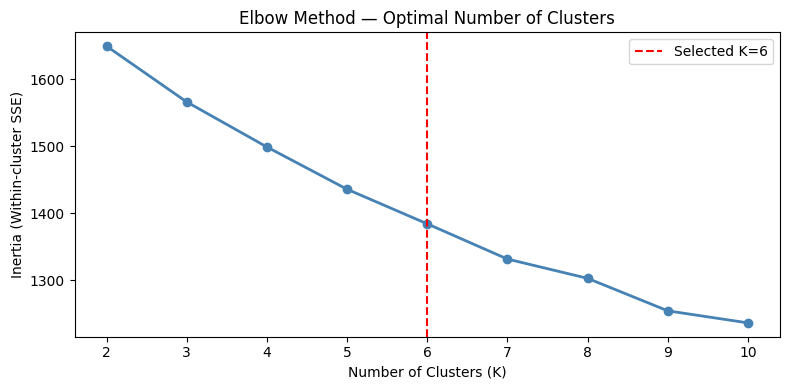

Inertia values: [1649.8, 1566.4, 1499.1, 1436.0, 1384.3, 1331.6, 1302.8, 1254.3, 1236.3]


In [16]:
# Determine optimal K using Elbow Method
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix_en)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=6, color='red', linestyle='--', label='Selected K=6')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster SSE)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Inertia values: {[round(i,1) for i in inertias]}")

In [17]:
# Fit final K-Means model
# K=6 chosen: matches the 5 diagnosis categories + 1 mixed/other cluster
num_clusters = 6   # Hip / Knee / Bone / Musculoskeletal / Spine / Other
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10, max_iter=300)
kmeans.fit(tfidf_matrix_en)

df_en['cluster'] = kmeans.labels_

# Cluster size distribution
cluster_counts = df_en['cluster'].value_counts().sort_index()
print(f"K-Means fitted with K={num_clusters}")
print(f"\nCluster size distribution:")
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count} documents")

# Cluster vs Diagnosis Category cross-tab
print(f"\nCluster ↔ Diagnosis Category mapping:")
print(pd.crosstab(df_en['cluster'], df_en['Diagnosis Category']))

# Label clusters by dominant diagnosis category

def get_cluster_label(cluster_id):
    """Return dominant diagnosis category for a cluster."""
    cluster_docs = df_en[df_en['cluster'] == cluster_id]
    return cluster_docs['Diagnosis Category'].value_counts().index[0]

cluster_labels = {i: get_cluster_label(i) for i in range(num_clusters)}

print("Cluster ---> Dominant Label mapping:")
for cid, label in cluster_labels.items():
    count = (df_en['cluster'] == cid).sum()
    print(f"  Cluster {cid}: {label:<30} ({count} docs)")

svd = TruncatedSVD(n_components=50, random_state=42)
normalizer = Normalizer(copy=False)
lsa_pipeline = make_pipeline(svd, normalizer)

X_lsa = lsa_pipeline.fit_transform(tfidf_matrix_en)

# Step 2: Reduce further to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_lsa)

print(f"Original TF-IDF shape : {tfidf_matrix_en.shape}")
print(f"After LSA (50 dims)   : {X_lsa.shape}")
print(f"After PCA (2 dims)    : {X_2d.shape}")
print(f"Variance explained    : {pca.explained_variance_ratio_.sum():.2%}")

K-Means fitted with K=6

Cluster size distribution:
  Cluster 0: 186 documents
  Cluster 1: 304 documents
  Cluster 2: 531 documents
  Cluster 3: 177 documents
  Cluster 4: 401 documents
  Cluster 5: 583 documents

Cluster ↔ Diagnosis Category mapping:
Diagnosis Category  Bone-related disorders  Hip-related disorders  \
cluster                                                             
0                                        0                    186   
1                                      299                      4   
2                                        0                    308   
3                                        0                    177   
4                                        0                      0   
5                                        0                    583   

Diagnosis Category  Musculoskeletal disorders  Other  Spinal disorders  \
cluster                                                                  
0                                           0 

K-Means complete. Cluster × Language distribution:
language    en    hi    pa
cluster                   
0            0   927     0
1            0     0  1255
2            0     1   927
3         1258     0     0
4            0  1254     0
5          924     0     0


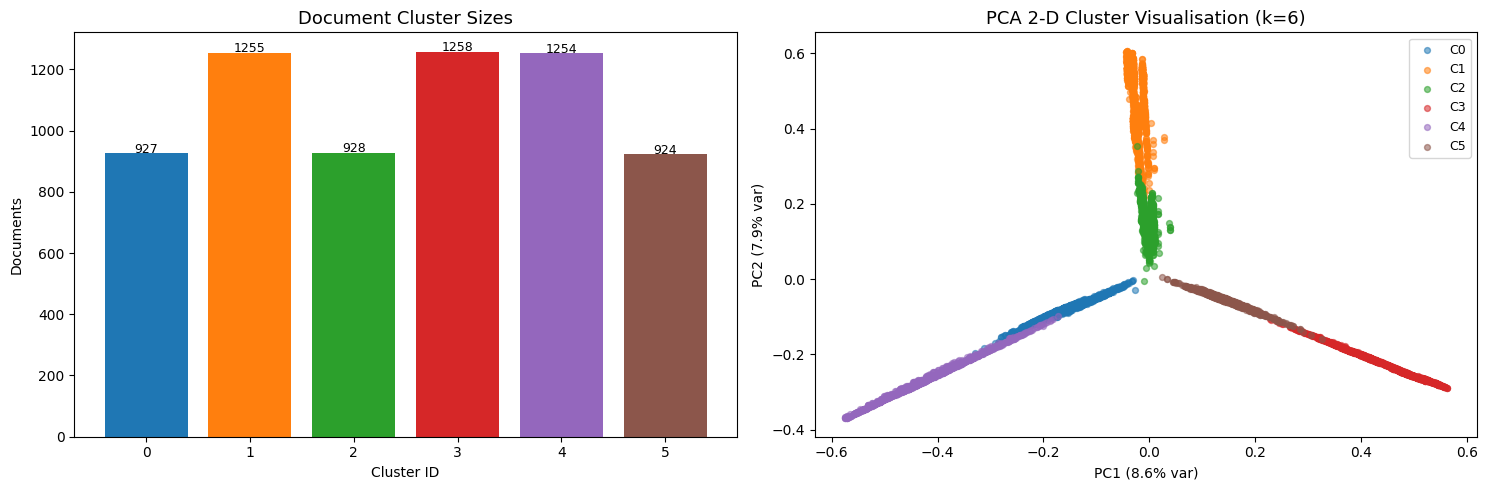

Saved cluster_visualisation.png
Cluster 0: 927 docs, example category: कूल्हे से संबंधित विकार
Cluster 1: 1255 docs, example category: ਕਮਰ ਨਾਲ ਸਬੰਧਤ ਵਿਕਾਰ
Cluster 2: 928 docs, example category: अन्य
Cluster 3: 1258 docs, example category: Hip-related disorders
Cluster 4: 1254 docs, example category: कूल्हे से संबंधित विकार
Cluster 5: 924 docs, example category: Unknown

Top-5 terms per cluster centroid:
 Cluster 0: हड्डियों, ।, संधियों, मांसपेशियों, लक्षण
 Cluster 1: ਕਮਰ, ਸੀਮਤ, ਨੈਕਰੋਸਿਸ, ਅਵੈਸਕੁਲਰ, ਦਰਦ
 Cluster 2: ਜੋੜਾਂ, ਹੱਡੀਆਂ, ਦਰਦ, ਸੋਜ, ਗਠੀਏ
 Cluster 3: hip, necrosi, avascular, limit, movement
 Cluster 4: कूल्हे, गति, नेक्रोसिस, अस्वास्कुलर, दोनों
 Cluster 5: joint, bone, stiff, fractur, osteoarthr


In [18]:
# ================================================================
#  K-MEANS DOCUMENT CLUSTERING + VISUALISATION
# ================================================================

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=15, max_iter=300)
corpus_df['cluster'] = kmeans.fit_predict(tfidf_matrix)
print('K-Means complete. Cluster × Language distribution:')
print(corpus_df.groupby(['cluster','language']).size().unstack(fill_value=0).to_string())
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Bar chart
counts  = corpus_df['cluster'].value_counts().sort_index()
palette = sns.color_palette('tab10', num_clusters)
axes[0].bar(counts.index, counts.values, color=palette)
axes[0].set_title('Document Cluster Sizes', fontsize=13)
axes[0].set_xlabel('Cluster ID'); axes[0].set_ylabel('Documents')
for i,v in enumerate(counts.values): axes[0].text(i, v+1, str(v), ha='center', fontsize=9)
# PCA 2-D scatter
pca  = PCA(n_components=2, random_state=42)
Xpca = pca.fit_transform(tfidf_matrix.toarray())
for c in range(num_clusters):
    mask = corpus_df['cluster'] == c
    axes[1].scatter(Xpca[mask,0], Xpca[mask,1], c=[palette[c]], label=f'C{c}', alpha=0.55, s=18)
axes[1].set_title(f'PCA 2-D Cluster Visualisation (k={num_clusters})', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('cluster_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved cluster_visualisation.png')

# Also print a sample of documents per cluster
for c in range(num_clusters):
    sample_cat = corpus_df[corpus_df['cluster']==c]['category'].iloc[0] if len(corpus_df[corpus_df['cluster']==c])>0 else "N/A"
    print(f"Cluster {c}: {len(corpus_df[corpus_df['cluster']==c])} docs, example category: {sample_cat}")

print('\nTop-5 terms per cluster centroid:')
order_c = kmeans.cluster_centers_.argsort()[:,::-1]
for c in range(num_clusters):
    terms = [vocab[i] for i in order_c[c,:5]]
    print(f" Cluster {c}: {', '.join(terms)}")

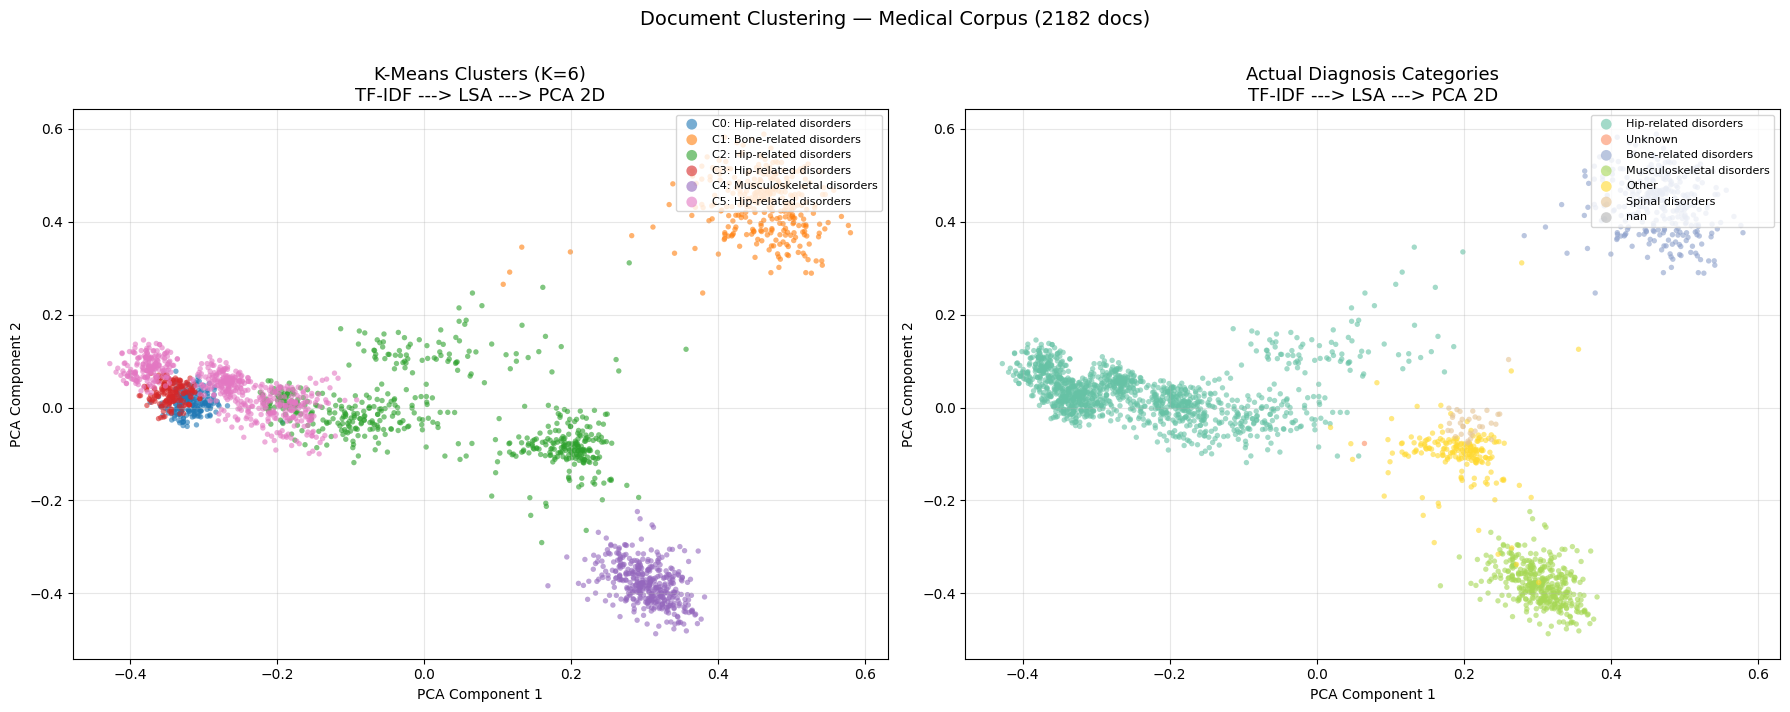

Cluster visualization saved as 'cluster_visualization.png'


In [19]:
# Cluster Visualization (main deliverable plot)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = cm.tab10(np.linspace(0, 0.6, num_clusters))

# --- Plot 1: Colored by K-Means cluster ---
ax1 = axes[0]
for cid in range(num_clusters):
    mask = df_en['cluster'] == cid
    ax1.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=[colors[cid]], label=f"C{cid}: {cluster_labels[cid]}",
        s=15, alpha=0.6, edgecolors='none'
    )

ax1.set_title('K-Means Clusters (K=6)\nTF-IDF ---> LSA ---> PCA 2D', fontsize=13)
ax1.set_xlabel('PCA Component 1')
ax1.set_ylabel('PCA Component 2')
ax1.legend(loc='upper right', fontsize=8, markerscale=2)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Colored by actual Diagnosis Category ---
ax2 = axes[1]
categories = df_en['Diagnosis Category'].unique()
cat_colors = cm.Set2(np.linspace(0, 1, len(categories)))

for i, cat in enumerate(categories):
    mask = df_en['Diagnosis Category'] == cat
    ax2.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=[cat_colors[i]], label=cat,
        s=15, alpha=0.6, edgecolors='none'
    )

ax2.set_title('Actual Diagnosis Categories\nTF-IDF ---> LSA ---> PCA 2D', fontsize=13)
ax2.set_xlabel('PCA Component 1')
ax2.set_ylabel('PCA Component 2')
ax2.legend(loc='upper right', fontsize=8, markerscale=2)
ax2.grid(True, alpha=0.3)

plt.suptitle('Document Clustering — Medical Corpus (2182 docs)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cluster visualization saved as 'cluster_visualization.png'")

# Cross-Lingual Retrieval (Section- 4.4)

## Multilingual Semantic Embeddings — SentenceTransformer

**Model:** `paraphrase-multilingual-MiniLM-L12-v2`
- 384-dimensional shared vector space for 50+ languages
- Downloads ~471 MB on first run
- L2-normalised embeddings ---> dot product equals cosine similarity (fast)
This implements the **Shared Embedding Approach** (Req 4.4). A Hindi query is *directly* projected near semantically equivalent English documents — no translation required.

In [20]:
# ================================================================
#   SENTENCETRANSFORMER MULTILINGUAL EMBEDDINGS
# ================================================================
print('Loading SentenceTransformer')
st_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2',device = "cuda" if torch.cuda.is_available() else "cpu")
print('Encoding corpus …')
corpus_embeddings = st_model.encode(
    corpus_df['original_text'].tolist(),
    batch_size=64, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True,
)
print(f'\nEmbedding matrix: {corpus_embeddings.shape}')
# Sanity check: EN-HI query pairs should score > 0.7
pairs = [
    ('hip pain',           'कूल्हे का दर्द'),
    ('knee stiffness',     'घुटने की जकड़न'),
    ('bone fracture',      'हड्डी का फ्रैक्चर'),
    ('spine disc herniation', 'L4-L5 डिस्क हर्नियेशन'),
]
print('\nCross-lingual similarity (EN ↔ HI):')
for en, hi in pairs:
    e1 = st_model.encode(en, normalize_embeddings=True)
    e2 = st_model.encode(hi, normalize_embeddings=True)
    print(f"  '{en}' ↔ '{hi}' ---> cosine = {float(e1 @ e2):.4f}")


Loading SentenceTransformer
Encoding corpus …


Batches:   0%|          | 0/103 [00:00<?, ?it/s]


Embedding matrix: (6546, 384)

Cross-lingual similarity (EN ↔ HI):
  'hip pain' ↔ 'कूल्हे का दर्द' ---> cosine = 0.5993
  'knee stiffness' ↔ 'घुटने की जकड़न' ---> cosine = 0.8124
  'bone fracture' ↔ 'हड्डी का फ्रैक्चर' ---> cosine = 0.8142
  'spine disc herniation' ↔ 'L4-L5 डिस्क हर्नियेशन' ---> cosine = 0.2313


## Unified Cross-Lingual Search Engine

Hindi query ---> English documents
<br/>
English query ---> Hindi documents

In [21]:
# ================================================================
# CROSS-LINGUAL HYBRID SEARCH ENGINE
# ================================================================
ALPHA = 0.4  # TF-IDF weight; (1-ALPHA) goes to semantic cosine similarity
def detect_language(text):
    if re.search(r'[\u0A00-\u0A7F]', text): return 'pb'
    if re.search(r'[\u0900-\u097F]', text): return 'hi'
    return 'en'
    
def translate_safe(text, src, tgt):
    try: return GoogleTranslator(source=src, target=tgt).translate(text) or text
    except: return text
        
def generate_snippet(full_text, query_tokens, window=160):
    lower, best = full_text.lower(), len(full_text)
    for t in query_tokens:
        pos = lower.find(t.lower())
        if 0 <= pos < best: best = pos
    s = max(0, best - window // 2)
    e = min(len(full_text), s + window)
    snip = full_text[s:e]
    return ('...' if s else '') + snip + ('...' if e < len(full_text) else '')
    
def highlight_terms(text, tokens):
    for t in sorted(tokens, key=len, reverse=True):
        if len(t) > 2:
            text = re.sub(re.escape(t), f'**{t.upper()}**', text, flags=re.IGNORECASE)
    return text
    
def search(query, top_k=10, use_expansion=True, alpha=ALPHA):
    q_lang = detect_language(query)
    if q_lang == 'hi':
        q_en = translate_safe(query, 'hi', 'en'); q_hi = query
    elif q_lang == 'pb':
        q_en = translate_safe(query, 'pa', 'en'); q_hi = translate_safe(query, 'pa', 'hi')
    else:
        q_en = query; q_hi = translate_safe(query, 'en', 'hi')
    combined_proc = (preprocess_english(q_en) + ' ' + preprocess_hindi(q_hi)).strip()
    if use_expansion: combined_proc = expand_query_prf(combined_proc)
    # TF-IDF retrieval
    qv       = tfidf_vectorizer.transform([combined_proc])
    tfidf_sc = cosine_similarity(qv, tfidf_matrix).flatten()
    # Semantic retrieval (cross-lingual shared space)
    q_emb    = st_model.encode(query, normalize_embeddings=True)
    sem_sc   = corpus_embeddings @ q_emb
    hybrid   = alpha * tfidf_sc + (1 - alpha) * sem_sc
    top_idx  = hybrid.argsort()[-top_k:][::-1]
    q_tok    = set(q_en.lower().split() + q_hi.split())
    results  = []
    for idx in top_idx:
        if hybrid[idx] > 1e-6:
            r = corpus_df.iloc[idx]
            snip = generate_snippet(r['original_text'], q_tok)
            results.append({
                'doc_id': r['doc_id'], 'score': round(float(hybrid[idx]), 4),
                'tfidf': round(float(tfidf_sc[idx]), 4),
                'sem': round(float(sem_sc[idx]), 4),
                'language': r['language'], 'category': r['category'],
                'snippet': highlight_terms(snip, q_tok),
            })
    return results
    
# ── Demo 1: Hindi ---> English + Hindi documents ─────────
print('=' * 60)
print('DEMO 1: Hindi query ---> multilingual results')
print('=' * 60)
for r in search('कूल्हे का दर्द')[:4]:
    print(f"[{r['language'].upper()}] score={r['score']} ({r['category']})")
    print(f"  {r['snippet']}\n")
print('=' * 60)
print('DEMO 2: English query ---> Hindi + English documents')
print('=' * 60)
for r in search('bone fracture treatment')[:4]:
    print(f"[{r['language'].upper()}] score={r['score']} ({r['category']})")
    print(f"  {r['snippet']}\n")


DEMO 1: Hindi query ---> multilingual results
[HI] score=0.5275 (कूल्हे से संबंधित विकार)
  आर्थ्राइटिक **कूल्हे** (ऐसिटैबुलर फ्रैक्चर) कूल्हों में **दर्द**, **कूल्हे** की जकड़न, चलने में कठिनाई, **कूल्हे** की लचीलापन में कमी "प्रभावित क्षेत्र में पुराना **दर्द**।

[HI] score=0.5255 (कूल्हे से संबंधित विकार)
  आर्थ्राइटिक **कूल्हे** कूल्हों में **दर्द**, **कूल्हे** की जकड़न, चलने में कठिनाई, **कूल्हे** की लचीलापन में कमी "प्रभावित क्षेत्र में पुराना **दर्द**।

[EN] score=0.5218 (Hip-related disorders)
  Avascular Necrosis of the Right **HIP** Discomfort in groin, **HIP** stiffness, Difficulty bearing weight, Decreased **HIP** flexibility Frequent joint **PAIN** and stiffness.

[EN] score=0.5094 (Hip-related disorders)
  Avascular Necrosis of the Right **HIP** Discomfort in groin, **HIP** stiffness, Trouble with weight support, Decreased **HIP** flexibility Frequent joint **PAIN** and stiffness...

DEMO 2: English query ---> Hindi + English documents
[EN] score=0.7095 (Bone-related diso

In [22]:
        
def cross_lingual_retrieve(query_raw, top_k=10, verbose=True):
    """
    Unified retrieval supporting English and Hindi queries.

    English query ---> translate EN--->HI ---> search Hindi corpus
    Hindi query   ---> translate HI--->EN ---> search English corpus (+ expansion)
    """
    lang = detect_language(query_raw)
    print(lang)

    #  Test both directions for both languages


    if verbose:
        print(f"Query             : '{query_raw}'")
        print(f"Detected language : {lang.upper()}")

    if lang == 'hi':
        # Hindi query ---> English documents
        translated = translate_safe(query_raw,'hi','en')  # translate_to_english
        if verbose:
            print(f"Translated (HI--->EN): '{translated}'")
            print(f"Searching         : English corpus")
        expanded_tokens = expand_query(translated, verbose=False)
        query_vec_en = tfidf_vectorizer_en.transform([' '.join(expanded_tokens)])
        similarities = cosine_similarity(query_vec_en, tfidf_matrix_en).flatten()
        source_df = df_en
        result_lang = 'English'

    else:
        # English query ---> Hindi documents
        translated = translate_safe(query_raw,'en','hi')   # translate_to_hindi
        if verbose:
            print(f"Translated (EN--->HI): '{translated}'")
            print(f"Searching         : Hindi corpus")
        query_vec_en = tfidf_vectorizer_hi.transform([translated])
        similarities = cosine_similarity(query_vec_en, tfidf_matrix_hi).flatten()
        source_df = df_hi
        result_lang = 'Hindi'

    top_indices = similarities.argsort()[::-1][:top_k]
    results = source_df.iloc[top_indices][
        ['patient_id', 'Diagnosis', 'Diagnosis Category',
         'symptoms', 'treatment', 'Patient History']
    ].copy()
    results['cosine_score'] = similarities[top_indices]
    results['result_language'] = result_lang
    results = results[results['cosine_score'] > 0].reset_index(drop=True)
    results.index += 1
    return results, lang, translated

In [23]:
# Fit and transform English corpus


print(f"English TF-IDF Matrix shape : {tfidf_matrix_en.shape}")
print(f"  ---> {tfidf_matrix_en.shape[0]} documents × {tfidf_matrix_en.shape[1]} terms")
print(f"Matrix sparsity     : {(1 - tfidf_matrix_en.nnz / (tfidf_matrix_en.shape[0] * tfidf_matrix_en.shape[1])):.2%}")
print()
print(f"Hindi TF-IDF Matrix : {tfidf_matrix_hi.shape}")
print(f"  ---> {tfidf_matrix_hi.shape[0]} docs × {tfidf_matrix_hi.shape[1]} char n-gram features")
print(f"Sparsity            : {(1 - tfidf_matrix_hi.nnz / (tfidf_matrix_hi.shape[0] * tfidf_matrix_hi.shape[1])):.2%}")

print("="*60)
print("TEST 1: Hindi query ---> English documents")
print("="*60)
res1, _, _ = cross_lingual_retrieve("कूल्हे में दर्द का इलाज")
print(f"\nTop-5 results:")
print(res1[['patient_id','Diagnosis','cosine_score','result_language']].head(5).to_string())

print("\n" + "="*60)
print("TEST 2: English query ---> Hindi documents")
print("="*60)
res2, _, _ = cross_lingual_retrieve("hip pain treatment")
print(f"\nTop-5 results:")
print(res2[['patient_id','Diagnosis','cosine_score','result_language']].head(5).to_string())

print("\n" + "="*60)
print("TEST 3: Hindi query ---> English documents (fracture)")
print("="*60)
res3, _, _ = cross_lingual_retrieve("हड्डी का फ्रैक्चर")
print(f"\nTop-5 results:")
print(res3[['patient_id','Diagnosis','cosine_score','result_language']].head(5).to_string())

English TF-IDF Matrix shape : (2182, 462)
  ---> 2182 documents × 462 terms
Matrix sparsity     : 95.59%

Hindi TF-IDF Matrix : (2182, 6213)
  ---> 2182 docs × 6213 char n-gram features
Sparsity            : 93.02%
TEST 1: Hindi query ---> English documents
hi
Query             : 'कूल्हे में दर्द का इलाज'
Detected language : HI
Translated (HI--->EN): 'hip pain treatment'
Searching         : English corpus

Top-5 results:
Empty DataFrame
Columns: [patient_id, Diagnosis, cosine_score, result_language]
Index: []

TEST 2: English query ---> Hindi documents
en
Query             : 'hip pain treatment'
Detected language : EN
Translated (EN--->HI): 'कूल्हे के दर्द का इलाज'
Searching         : Hindi corpus

Top-5 results:
   patient_id                               Diagnosis  cosine_score result_language
1        9841  दाहिने कूल्हे का अस्वास्कुलर नेक्रोसिस      0.372407           Hindi
2        1174  दाहिने कूल्हे का अस्वास्कुलर नेक्रोसिस      0.371727           Hindi
3        3648            

## (Optional) Advanced Optimisation: SentenceTransformer Dense Retrieval

To improve cross‑lingual retrieval, we add a dense retrieval pipeline using a multilingual SentenceTransformer model (`BAAI/bge-m3`). This model natively supports English and Hindi, so no explicit translation is needed. We also show how dense retrieval can be combined with TF‑IDF (hybrid) for even better results.
*Note*: This section is not mandatory but demonstrates an advanced optimisation of the required cross‑lingual and retrieval components.

In [24]:

# Load multilingual model
dense_model = SentenceTransformer('BAAI/bge-m3', device = "cuda" if torch.cuda.is_available() else "cpu") # paraphrase-multilingual-MiniLM-L12-v2
doc_embeddings = dense_model.encode(corpus_df['clean_text'].tolist(), convert_to_tensor=True, show_progress_bar=True)
print(f"Document embeddings shape: {doc_embeddings.shape}")
def dense_search(query, top_k=10):
    query_emb = dense_model.encode(query, convert_to_tensor=True)
    cos_scores = util.cos_sim(query_emb, doc_embeddings)[0]
    top_results = torch.topk(cos_scores, k=min(top_k, len(cos_scores)))
    indices = top_results.indices.cpu().numpy()
    scores = top_results.values.cpu().numpy()
    results = []
    for idx, score in zip(indices, scores):
        row = corpus_df.iloc[idx]
        results.append({
            'id': row['doc_id'],
            'score': float(score),
            'language': row['language'],
            'text': row['original_text'][:200] + '...',
            'category': row['category']
        })
    return results
# Test dense retrieval on a Hindi query
print("Dense retrieval test:")
dense_res = dense_search("कूल्हे का दर्द", top_k=5)
for i, r in enumerate(dense_res):
    print(f"{i+1}. [{r['language'].upper()}] Score={r['score']:.4f} - {r['category']}")
# Optional: Hybrid fusion (RRF) would combine TF‑IDF and dense scores


Batches:   0%|          | 0/205 [00:00<?, ?it/s]

Document embeddings shape: torch.Size([6546, 1024])
Dense retrieval test:
1. [HI] Score=0.6629 - कूल्हे से संबंधित विकार
2. [HI] Score=0.6594 - कूल्हे से संबंधित विकार
3. [HI] Score=0.6594 - कूल्हे से संबंधित विकार
4. [HI] Score=0.6571 - कूल्हे से संबंधित विकार
5. [HI] Score=0.6571 - कूल्हे से संबंधित विकार


# Web Search UI (Streamlit App) (Section- 4.5)

In [25]:
# ================================================================
# GENERATE app.py (Streamlit Web Interface)
# ================================================================
app_src = textwrap.dedent('''
import pip
pip.main(['install'] + "pandas numpy scikit-learn nltk indic-nlp-library deep-translator streamlit sentence-transformers rank-bm25 torch".split())
import streamlit as st
import pickle, re, os, sys, numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from deep_translator import GoogleTranslator
from sentence_transformers import SentenceTransformer
import nltk, string
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from indicnlp.tokenize import indic_tokenize
from indicnlp.normalize.indic_normalize import DevanagariNormalizer, GurmukhiNormalizer
import torch
lang_map = {'English':'en','Hindi':'hi','Punjabi':'pa'}
st.set_page_config(page_title='MediSearch', page_icon='\U0001fa7a', layout='wide')
st.title('\U0001fa7a 🏥MediSearch — Multilingual Orthopedic Search Engine🔍')
st.caption(f'Supports  {lang_map} | TF-IDF + Semantic Hybrid Retrieval')
nltk.download('punkt', quiet=True); nltk.download('stopwords', quiet=True)
EN_SW = set(stopwords.words('english'))
HI_SW = set([
    'के', 'का', 'एक', 'में', 'की', 'है', 'यह', 'और', 'से', 'हैं', 'को', 'पर', 'इस',
    'होता', 'कि', 'जो', 'कर', 'मे', 'गया', 'करने', 'किया', 'लिये', 'अपने', 'ने',
    'बनी', 'नहीं', 'तो', 'ही', 'या', 'एवं', 'दिया', 'हो', 'इसका', 'था', 'द्वारा',
    'हुआ', 'तक', 'साथ', 'गये', 'थे', 'दो', 'वे', 'होते', 'थी', 'हुई', 'ई', 'जा',
    'सकता', 'होने', 'गई', 'अत', 'अपना', 'इसमें', 'सकते', 'देखा', 'चलते', 'आदि',
    'लेकर', 'बड़ा', 'जाता', 'दोस्त'
])
stemmer = PorterStemmer(); norm_hi = DevanagariNormalizer()
PA_SW = {
'ਦੇ','ਦੀ','ਦਾ','ਵਿੱਚ','ਨੂੰ','ਕਿ','ਅਤੇ','ਹੈ','ਹਨ','ਇਸ','ਦੀਆਂ','ਨਾਲ','ਇੱਕ','ਤੇ','ਇਹ','ਉਹ','ਤੋਂ',
}
stemmer = PorterStemmer(); norm_pa = GurmukhiNormalizer()
def whitespace_tokenizer(x):
    return x.split()
def pre_en(t):
    t = t.lower(); t = re.sub(r'[^\w\s]',' ',t)
    return ' '.join(stemmer.stem(w) for w in word_tokenize(t) if w not in EN_SW and w.isalpha())
def pre_hi(t):
    t = norm_hi.normalize(t); t = re.sub(r'[^\w\s]',' ',t)
    return ' '.join(w for w in indic_tokenize.trivial_tokenize(t,'hi') if w not in HI_SW)
def pre_pa(t):
    t = norm_hi.normalize(t); t = re.sub(r'[^\w\s]',' ',t)
    return ' '.join(w for w in indic_tokenize.trivial_tokenize(t,'pa') if w not in PA_SW)
def detect_lang(t):
    if re.search(r'[\u0A00-\u0A7F]',t): return 'pa'
    if re.search(r'[\u0900-\u097F]',t): return 'hi'
    return 'en'
def translate_safe(t,s,tg):
    try: return GoogleTranslator(source=s,target=tg).translate(t) or t
    except: return t
@st.cache_resource(show_spinner="Loading search engine...")
def load():
    with open("search_artifacts.pkl", "rb") as f:
        arts = pickle.load(f)
    model = SentenceTransformer("all-MiniLM-L6-v2",device = "cuda" if torch.cuda.is_available() else "cpu")
    # 🚀 Precompute vocabulary embeddings once to enable semantic expansion
    if isinstance(arts['vocab'], dict):
        vocab_list = list(arts['vocab'].keys())
    else:
        vocab_list = arts['vocab']
        
    arts['vocab_list'] = vocab_list
    arts['vocab_embeddings'] = model.encode(vocab_list, normalize_embeddings=True, show_progress_bar=False)
    arts["st_model"] = model
    return arts
arts = load()
corpus_df = arts['corpus_df']; tv = arts['tfidf_vectorizer']
tm = arts['tfidf_matrix'];     ce = arts['corpus_embeddings']
st_m = arts['st_model'];       vc_list = arts['vocab_list']; vc_emb = arts['vocab_embeddings']
# 🧬 New Semantic SentenceTransformer Query Expansion
def expand(proc, raw_query, k=5):
    # Encode the raw user query
    qe = st_m.encode([raw_query], normalize_embeddings=True)
    
    # Measure cosine similarity against the whole vocabulary
    sc = (vc_emb @ qe.T).flatten()
    
    qset = set(proc.split())
    ranked = sorted([(vc_list[i], sc[i]) for i in range(len(vc_list)) if vc_list[i] not in qset], key=lambda x: -x[1])
    
    # Return query with top k semantically nearest words
    return proc + ' ' + ' '.join(t for t, _ in ranked[:k])

def do_search(q, top_k=10, alpha=0.4, use_alpha=True, expand_q=True):
    ql=detect_lang(q)
    q_en=translate_safe(q,'hi','en') if ql=='hi' else (translate_safe(q,'pa','en') if ql=='pa' else q)
    q_hi=translate_safe(q,'en','hi') if ql=='en' else (translate_safe(q,'pa','hi') if ql=='pa' else q)
    q_pa=translate_safe(q,'en','pa') if ql=='en' else (translate_safe(q,'hi','pa') if ql=='hi' else q)
    proc=(pre_en(q_en)+' '+pre_hi(q_hi)+' '+pre_hi(q_pa)).strip()
    
    # 💥 Passes raw string 'q' to target vector engine
    if expand_q: proc=expand(proc, q)
    
    qv=tv.transform([proc]); tsc=cosine_similarity(qv,tm).flatten()
    qe=st_m.encode(q,normalize_embeddings=True); ssc=ce@qe
    
    if use_alpha:
        hs = alpha * tsc + (1 - alpha) * ssc
    else:
        hs = 0.5 * tsc + 0.5 * ssc
        
    idx=hs.argsort()[-top_k:][::-1]
    out=[]
    for i in idx:
        if hs[i]>1e-6:
            r=corpus_df.iloc[i]
            snip=r['original_text'][:200]+'...'
            for w in set(q_en.lower().split()):
                if len(w)>2: snip=re.sub(re.escape(w),f'**{w.upper()}**',snip,flags=re.IGNORECASE)
            out.append({'doc_id':r['doc_id'],'alpha':alpha if use_alpha else 0.5,'score':round(float(hs[i]),4),
                        'lang':r['language'],'cat':r['category'],'snippet':snip,
                        'tf_score': round(float(tsc[i]), 4), 'cos_score': round(float(ssc[i]), 4),'input_lang':ql,'translates':[q_en,q_hi,q_pa]})
    return out
with st.sidebar:
    st.header('Search Settings')
    top_k = st.slider('Top-K',5,20,10)
    use_alpha = st.checkbox('Enable Alpha Weighting \n(Score = α x TF_IDF + (1-α) x CosineSimilarity)', True)
    
    if use_alpha:
        alpha = st.slider('Threshold weight (Alpha)',0.0,1.0,0.4,0.05)
    else:
        alpha = 0.5
        st.info('Using equal weighting (0.5 TF-IDF + 0.5 Cosine)')
        
    expand_q = st.checkbox('Semantic Query Expansion (ST)',True)
    lang_f = st.multiselect('Language filter',['en','hi','pa'],default=['en','hi','pa'])
    
    st.markdown('---')
    st.subheader('📌 Score Filters')
    tf_threshold = st.slider('Minimum TF-IDF Score', 0.0, 1.0, 0.0, 0.05)
    cos_threshold = st.slider('Minimum Cosine Score', 0.0, 1.0, 0.0, 0.05)
    
    st.progress(int((1-cos_threshold) * 100))
    st.caption(f"Hiding documents with cosine scores below **{cos_threshold}**")
    
    st.markdown('---')
    st.subheader('📊 Vocabulary Size by Language')
    
    v_pa = [w for w in vc_list if re.search(r'[\u0A00-\u0A7F]', str(w))]
    v_hi = [w for w in vc_list if re.search(r'[\u0900-\u097F]', str(w))]
    v_en = [w for w in vc_list if not re.search(r'[\u0A00-\u0A7F\u0900-\u097F]', str(w))]
    
    st.write(f"🇬🇧 **English:** {len(v_en)}")
    st.write(f"🇮🇳 **Hindi:** {len(v_hi)}")
    st.write(f"🌾 **Punjabi:** {len(v_pa)}")
    
    st_scores = st.empty()
    
    st.markdown('---')
    st.markdown('BITS Pilani — IR Assignment #2')
q = st.text_input('Enter query / प्रश्न दर्ज करें / ਸਵਾਲ ਦਾਖਲ ਕਰੋ :',  placeholder='E.g:  hip pain / कूल्हे का दर्द / ਕਮਰ ਦਰਦ')
if q.strip():
    with st.spinner('Searching ...'):
        raw_res = do_search(q.strip(), top_k=50, alpha=alpha, use_alpha=use_alpha, expand_q=expand_q)
        inp = raw_res[0]
        lang_label = "🇮🇳 Hindi (hi)" if inp['input_lang']=="hi"  else ("🇬🇧🏴󠁧󠁢󠁥󠁮󠁧󠁿 English (en)" if inp['input_lang']=="en" else "🇮🇳 Punjabi (pa)")
        if raw_res:
            all_tf = [r['tf_score'] for r in raw_res]
            all_cos = [r['cos_score'] for r in raw_res]
            
            mean_tf = sum(all_tf) / len(all_tf)
            mean_cos = sum(all_cos) / len(all_cos)
            
            if mean_tf + mean_cos > 1e-6:
                suggested_alpha = round(float(mean_cos / (mean_tf + mean_cos)), 2)
            else:
                suggested_alpha = 0.50
        else:
            suggested_alpha = 0.40
            
        res = [r for r in raw_res if r['lang'] in lang_f]
        res = [r for r in res if r['cos_score'] >= cos_threshold and r['tf_score'] >= tf_threshold]
        res = res[:top_k]
    
    st.success(
    f"Detected: {lang_label} | "
    f"Translated: {dict(zip(lang_map.keys(),inp['translates']))} "
    )
    st.markdown(f'**{len(res)} results** for *{q}*')
    
    if res:
        with st_scores.container():
            st.markdown('---')
            st.subheader('📈 Query Score Analytics')
            st.write(f"🎯 **Best TF-IDF Score:** {max([r['tf_score'] for r in res])}")
            st.write(f"🧬 **Best Cosine Score:** {max([r['cos_score'] for r in res])}")
            st.markdown(f"💡 **Suggested Alpha:** `{suggested_alpha}` (based on vector score ratios for this query)")
    
    for i,r in enumerate(res,1):
        st.markdown(f'**#{i} [{r["lang"]}]** `Score: {r["score"]}` | `Alpha: {r["alpha"]}` (TF-IDF: {r["tf_score"]} | Cosine: {r["cos_score"]} ) — {r["cat"]}')
        st.markdown(":yellow["+r['snippet']+']')
        for nm,sym in {k:v for k,v in lang_map.items() if v != r["lang"]}.items():
            st.markdown(f"*{nm} ({sym})  Translation: :blue[* {translate_safe(r['snippet'].replace('**', ''), r['lang'], sym)}]")
        st.divider()
else:
    st.info('Enter a query above to search.')
''')
with open('med_app.py', 'w', encoding='utf-8') as f:
    f.write(app_src)
print('med_app.py written.  Launch with: streamlit run med_app.py')


med_app.py written.  Launch with: streamlit run med_app.py


## Export Artifacts for Streamlit

In [26]:
# ================================================================
# PICKLE SEARCH ARTIFACTS FOR STREAMLIT
# ================================================================
print(tfidf_vectorizer)
artifacts = {
    'corpus_df': corpus_df,
    'tfidf_vectorizer': tfidf_vectorizer,
    'tfidf_matrix': tfidf_matrix,
    'corpus_embeddings': corpus_embeddings,
    'vocab': vocab
}
with open("search_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)
print('search_artifacts.pkl written.')
print('\n--- Submission checklist ---')
for fn in ['requirements.txt','med_app.py','search_artifacts.pkl',
           'cluster_visualisation.png','evaluation_metrics.png']:
    tag = 'YES' if os.path.exists(fn) else 'MISSING'
    print(f'  [{tag}]  {fn}')


TfidfVectorizer(lowercase=False, max_df=0.95, sublinear_tf=True,
                tokenizer=<function whitespace_tokenizer at 0x7f4b2ce5bd00>)
search_artifacts.pkl written.

--- Submission checklist ---
  [YES]  requirements.txt
  [YES]  med_app.py
  [YES]  search_artifacts.pkl
  [YES]  cluster_visualisation.png
  [YES]  evaluation_metrics.png


# Evaluation (Section- 5)

## Categorical calculations

In [27]:
#  Auto-generate 25 evaluation queries with ground truth

# Strategy: for each query, relevant docs = those whose Diagnosis Category
# or Diagnosis field contains the query's key terms
# We define ground truth as patient_ids matching the clinical intent

eval_queries = [
    # Hip-related (8 queries)
    {"query": "avascular necrosis hip",          "relevant_category": ["Hip-related disorders"],        "relevant_keywords": ["avascular", "necrosis", "hip"]},
    {"query": "bilateral hip pain",              "relevant_category": ["Hip-related disorders"],        "relevant_keywords": ["bilateral", "hip"]},
    {"query": "hip replacement surgery",         "relevant_category": ["Hip-related disorders"],        "relevant_keywords": ["hip", "replacement", "surgery"]},
    {"query": "hip stiffness mobility loss",     "relevant_category": ["Hip-related disorders"],        "relevant_keywords": ["hip", "stiff", "mobility"]},
    {"query": "avascular necrosis MRI",          "relevant_category": ["Hip-related disorders"],        "relevant_keywords": ["avascular", "mri"]},
    {"query": "hip pain weight management",      "relevant_category": ["Hip-related disorders"],        "relevant_keywords": ["hip", "weight"]},
    {"query": "femoral head necrosis",           "relevant_category": ["Hip-related disorders"],        "relevant_keywords": ["femoral", "necrosis"]},
    {"query": "hip arthritis elderly patient",   "relevant_category": ["Hip-related disorders"],        "relevant_keywords": ["hip", "arthrit"]},

    # Bone-related (5 queries)
    {"query": "bone fracture treatment",         "relevant_category": ["Bone-related disorders"],       "relevant_keywords": ["fractur", "bone"]},
    {"query": "osteoporosis bone density",       "relevant_category": ["Bone-related disorders"],       "relevant_keywords": ["osteoporosi", "bone", "densiti"]},
    {"query": "acetabular fracture diagnosis",   "relevant_category": ["Bone-related disorders"],       "relevant_keywords": ["acetabular", "fractur"]},
    {"query": "stress fracture rehabilitation",  "relevant_category": ["Bone-related disorders"],       "relevant_keywords": ["fractur", "rehab"]},
    {"query": "bone pain calcium deficiency",    "relevant_category": ["Bone-related disorders"],       "relevant_keywords": ["bone", "pain"]},

    # Musculoskeletal (5 queries)
    {"query": "joint inflammation arthritis",    "relevant_category": ["Musculoskeletal disorders"],    "relevant_keywords": ["joint", "inflamm", "arthrit"]},
    {"query": "muscle weakness fatigue",         "relevant_category": ["Musculoskeletal disorders"],    "relevant_keywords": ["muscl", "weak", "fatigu"]},
    {"query": "osteoarthritis knee joint",       "relevant_category": ["Musculoskeletal disorders"],    "relevant_keywords": ["osteoarthr", "joint"]},
    {"query": "joint stiffness physiotherapy",   "relevant_category": ["Musculoskeletal disorders"],    "relevant_keywords": ["joint", "stiff", "physiotherapi"]},
    {"query": "musculoskeletal pain management", "relevant_category": ["Musculoskeletal disorders"],    "relevant_keywords": ["muscl", "pain", "manag"]},

    # Spinal (4 queries)
    {"query": "spine inflammation therapy",      "relevant_category": ["Spinal disorders"],             "relevant_keywords": ["spine", "inflamm", "therapi"]},
    {"query": "lumbar back pain treatment",      "relevant_category": ["Spinal disorders"],             "relevant_keywords": ["lumbar", "spine", "pain"]},
    {"query": "spinal cord compression",         "relevant_category": ["Spinal disorders"],             "relevant_keywords": ["spinal", "compress"]},
    {"query": "vertebral fracture elderly",      "relevant_category": ["Spinal disorders"],             "relevant_keywords": ["vertebr", "fractur"]},

    # Mixed/cross-category (3 queries)
    {"query": "chronic pain physiotherapy rehabilitation",
                                                 "relevant_category": ["Hip-related disorders", "Musculoskeletal disorders", "Spinal disorders"],
                                                                                                        "relevant_keywords": ["physiotherapi", "rehabilit"]},
    {"query": "elderly patient mobility restriction",
                                                 "relevant_category": ["Hip-related disorders", "Musculoskeletal disorders"],
                                                                                                        "relevant_keywords": ["elderli", "mobil", "restrict"]},
    {"query": "pain management medications",     "relevant_category": ["Hip-related disorders", "Bone-related disorders", "Musculoskeletal disorders"],
                                                                                                        "relevant_keywords": ["pain", "manag", "medicat"]},
]

print(f"{len(eval_queries)} evaluation queries defined")
print(f"\nCategory breakdown:")

cat_count = Counter()
for q in eval_queries:
    for c in q['relevant_category']:
        cat_count[c] += 1
for cat, cnt in cat_count.items():
    print(f"  {cat}: {cnt} queries")

25 evaluation queries defined

Category breakdown:
  Hip-related disorders: 11 queries
  Bone-related disorders: 6 queries
  Musculoskeletal disorders: 8 queries
  Spinal disorders: 5 queries


In [28]:
# Build ground truth relevant set for each query

def get_ground_truth(query_dict):
    """
    Relevant documents = docs whose:
    1. Diagnosis Category matches the query's relevant_category AND
    2. At least one keyword appears in the document tokens
    """
    relevant_cats = query_dict['relevant_category']
    keywords = query_dict['relevant_keywords']

    # Filter by category first
    cat_mask = df_en['Diagnosis Category'].isin(relevant_cats)
    candidates = df_en[cat_mask]

    # Filter by keyword match in tokens
    def has_keyword(tokens):
        return any(kw in tokens for kw in keywords)

    keyword_mask = candidates['tokens'].apply(has_keyword)
    relevant_docs = candidates[keyword_mask]

    return set(relevant_docs['patient_id'].tolist())

# Test ground truth
sample = eval_queries[0]
gt = get_ground_truth(sample)
print(f"Query: '{sample['query']}'")
print(f"Ground truth size: {len(gt)} relevant documents")
print(f"Sample relevant IDs: {list(gt)[:5]}")

Query: 'avascular necrosis hip'
Ground truth size: 1258 relevant documents
Sample relevant IDs: [8193, 8195, 8197, 8199, 8217]


In [29]:
# Evaluation metrics: Precision, Recall, AP

def precision_at_k(retrieved_ids, relevant_ids, k=10):
    retrieved_k = retrieved_ids[:k]
    hits = sum(1 for doc in retrieved_k if doc in relevant_ids)
    return hits / k if k > 0 else 0.0

def recall_at_k(retrieved_ids, relevant_ids, k=10):
    retrieved_k = retrieved_ids[:k]
    hits = sum(1 for doc in retrieved_k if doc in relevant_ids)
    return hits / len(relevant_ids) if len(relevant_ids) > 0 else 0.0

def average_precision(retrieved_ids, relevant_ids, k=10):
    """Compute Average Precision (AP) for a single query."""
    retrieved_k = retrieved_ids[:k]
    hits = 0
    precision_sum = 0.0
    for i, doc in enumerate(retrieved_k, 1):
        if doc in relevant_ids:
            hits += 1
            precision_sum += hits / i
    if len(relevant_ids) == 0:
        return 0.0
    return precision_sum / min(len(relevant_ids), k)

print(" Evaluation metric functions defined")
print("   - precision_at_k(retrieved, relevant, k=10)")
print("   - recall_at_k(retrieved, relevant, k=10)")
print("   - average_precision(retrieved, relevant, k=10)")

# Run full evaluation over all 25 queries

results_log = []

for qdict in eval_queries:
    query_raw = qdict['query']
    relevant_ids = get_ground_truth(qdict)

    if len(relevant_ids) == 0:
        continue  # skip if no ground truth docs found

    # Retrieve top-10 with expansion
    res, _ = retrieve_with_expansion(query_raw, top_k=10, verbose=False)
    retrieved_ids = res['patient_id'].tolist()

    p10   = precision_at_k(retrieved_ids, relevant_ids, k=10)
    r10   = recall_at_k(retrieved_ids, relevant_ids, k=10)
    ap    = average_precision(retrieved_ids, relevant_ids, k=10)

    results_log.append({
        'query'         : query_raw,
        'category'      : ', '.join(qdict['relevant_category']),
        'relevant_docs' : len(relevant_ids),
        'retrieved_docs': len(retrieved_ids),
        'P@10'          : round(p10, 4),  # Precision
        'R@10'          : round(r10, 4),  # Recall
        'AP'            : round(ap, 4),   # Average Precision
    })

eval_df = pd.DataFrame(results_log)
print(f"Evaluated {len(eval_df)} queries\n")
print(eval_df[['query','relevant_docs','P@10','R@10','AP']].to_string(index=False))

 Evaluation metric functions defined
   - precision_at_k(retrieved, relevant, k=10)
   - recall_at_k(retrieved, relevant, k=10)
   - average_precision(retrieved, relevant, k=10)
Evaluated 24 queries

                                    query  relevant_docs  P@10   R@10     AP
                   avascular necrosis hip           1258   0.5 0.0040 0.2605
                       bilateral hip pain           1258   0.5 0.0040 0.2605
                  hip replacement surgery           1258   0.5 0.0040 0.2605
              hip stiffness mobility loss           1258   0.5 0.0040 0.2605
                   avascular necrosis MRI           1017   0.3 0.0029 0.1586
               hip pain weight management           1258   0.5 0.0040 0.2605
            hip arthritis elderly patient           1258   0.5 0.0040 0.2605
                  bone fracture treatment            299   0.1 0.0033 0.0333
                osteoporosis bone density            299   0.1 0.0033 0.0333
            acetabular fractur

In [30]:
#  Compute MAP and overall summary

MAP = eval_df['AP'].mean()
mean_P10 = eval_df['P@10'].mean()
mean_R10 = eval_df['R@10'].mean()

print("="*55)
print("  EVALUATION RESULTS SUMMARY")
print("="*55)
print(f"  Queries evaluated     : {len(eval_df)}")
print(f"  Mean Precision@10     : {mean_P10:.4f}  ({mean_P10*100:.1f}%)")
print(f"  Mean Recall@10        : {mean_R10:.4f}  ({mean_R10*100:.1f}%)")
print(f"  MAP (Mean Avg Prec.)  : {MAP:.4f}  ({MAP*100:.1f}%)")
print("="*55)

# Per-category breakdown
print("\nPer-category breakdown:")
for cat in eval_df['category'].unique():
    sub = eval_df[eval_df['category'] == cat]
    print(f"\n  {cat}")
    print(f"    Queries : {len(sub)}")
    print(f"    P@10    : {sub['P@10'].mean():.4f}")
    print(f"    R@10    : {sub['R@10'].mean():.4f}")
    print(f"    MAP     : {sub['AP'].mean():.4f}")

  EVALUATION RESULTS SUMMARY
  Queries evaluated     : 24
  Mean Precision@10     : 0.2500  (25.0%)
  Mean Recall@10        : 0.0081  (0.8%)
  MAP (Mean Avg Prec.)  : 0.1227  (12.3%)

Per-category breakdown:

  Hip-related disorders
    Queries : 7
    P@10    : 0.4714
    R@10    : 0.0038
    MAP     : 0.2459

  Bone-related disorders
    Queries : 5
    P@10    : 0.1000
    R@10    : 0.0033
    MAP     : 0.0333

  Musculoskeletal disorders
    Queries : 5
    P@10    : 0.1000
    R@10    : 0.0026
    MAP     : 0.0500

  Spinal disorders
    Queries : 4
    P@10    : 0.1000
    R@10    : 0.0303
    MAP     : 0.0267

  Hip-related disorders, Musculoskeletal disorders, Spinal disorders
    Queries : 1
    P@10    : 0.3000
    R@10    : 0.0084
    MAP     : 0.0819

  Hip-related disorders, Musculoskeletal disorders
    Queries : 1
    P@10    : 0.4000
    R@10    : 0.0041
    MAP     : 0.2105

  Hip-related disorders, Bone-related disorders, Musculoskeletal disorders
    Queries : 1
    

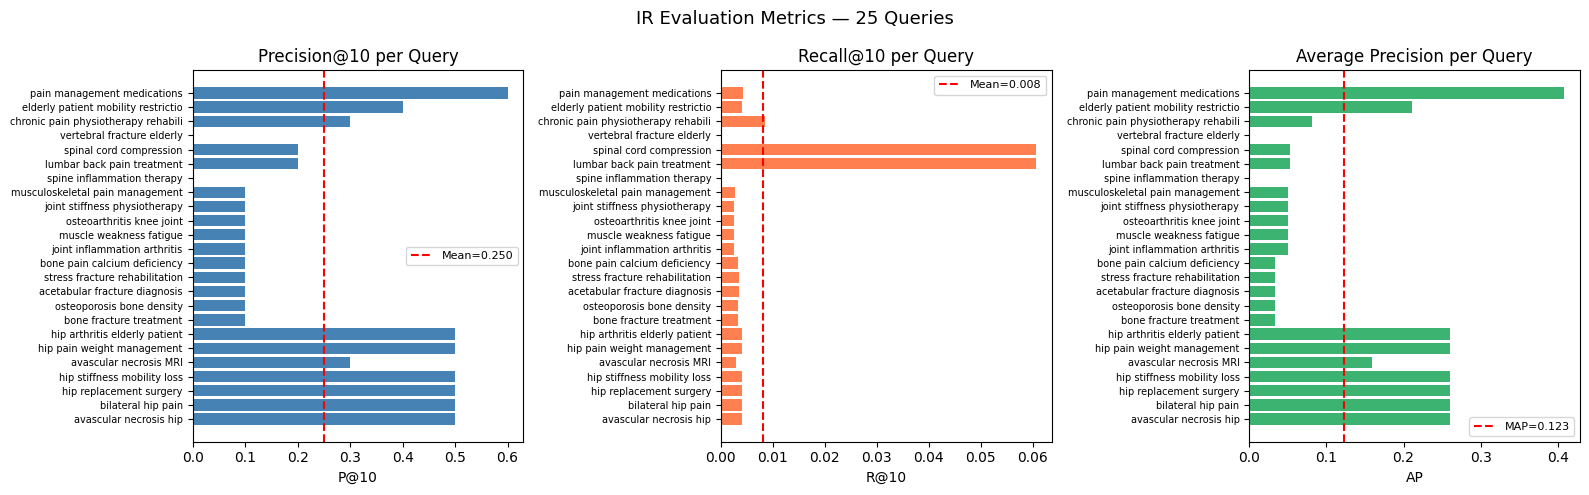

Evaluation visualization saved as 'evaluation_metrics.png'


In [31]:
# Evaluation visualization

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: P@10 per query
axes[0].barh(range(len(eval_df)), eval_df['P@10'], color='steelblue')
axes[0].set_yticks(range(len(eval_df)))
axes[0].set_yticklabels([q[:35] for q in eval_df['query']], fontsize=7)
axes[0].axvline(mean_P10, color='red', linestyle='--', label=f'Mean={mean_P10:.3f}')
axes[0].set_title('Precision@10 per Query')
axes[0].set_xlabel('P@10')
axes[0].legend(fontsize=8)

# Plot 2: Recall@10 per query
axes[1].barh(range(len(eval_df)), eval_df['R@10'], color='coral')
axes[1].set_yticks(range(len(eval_df)))
axes[1].set_yticklabels([q[:35] for q in eval_df['query']], fontsize=7)
axes[1].axvline(mean_R10, color='red', linestyle='--', label=f'Mean={mean_R10:.3f}')
axes[1].set_title('Recall@10 per Query')
axes[1].set_xlabel('R@10')
axes[1].legend(fontsize=8)

# Plot 3: AP per query
axes[2].barh(range(len(eval_df)), eval_df['AP'], color='mediumseagreen')
axes[2].set_yticks(range(len(eval_df)))
axes[2].set_yticklabels([q[:35] for q in eval_df['query']], fontsize=7)
axes[2].axvline(MAP, color='red', linestyle='--', label=f'MAP={MAP:.3f}')
axes[2].set_title('Average Precision per Query')
axes[2].set_xlabel('AP')
axes[2].legend(fontsize=8)

plt.suptitle('IR Evaluation Metrics — 25 Queries', fontsize=13)
plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Evaluation visualization saved as 'evaluation_metrics.png'")

## Evaluation Metrics comparison for English vs. Hindi

                Query Lang  Precision@10  Recall@10     AP
             hip pain   EN           1.0     0.0079 1.0000
      कूल्हे में दर्द   HI           0.6     0.0048 0.3731
        bone fracture   EN           1.0     0.0334 1.0000
    हड्डी का फ्रैक्चर   HI           1.0     0.0334 1.0000
       joint swelling   EN           1.0     0.0252 1.0000
       जोड़ों की सूजन   HI           0.0     0.0000 0.0000
   arthritis symptoms   EN           0.0     0.0000 0.0000
       गठिया के लक्षण   HI           0.0     0.0000 0.0000
         femur injury   EN           0.0     0.0000 0.0000
 जांघ की हड्डी की चोट   HI           0.0     0.0000 0.0000
  restricted movement   EN           1.0     0.0079 1.0000
       सीमित गतिशीलता   HI           0.0     0.0000 0.0000
      muscle weakness   EN           0.0     0.0000 0.0000
मांसपेशियों की कमजोरी   HI           0.0     0.0000 0.0000
         chronic pain   EN           0.7     0.0363 0.6367
        पुरानी बीमारी   HI           0.0     0.0000 0.00

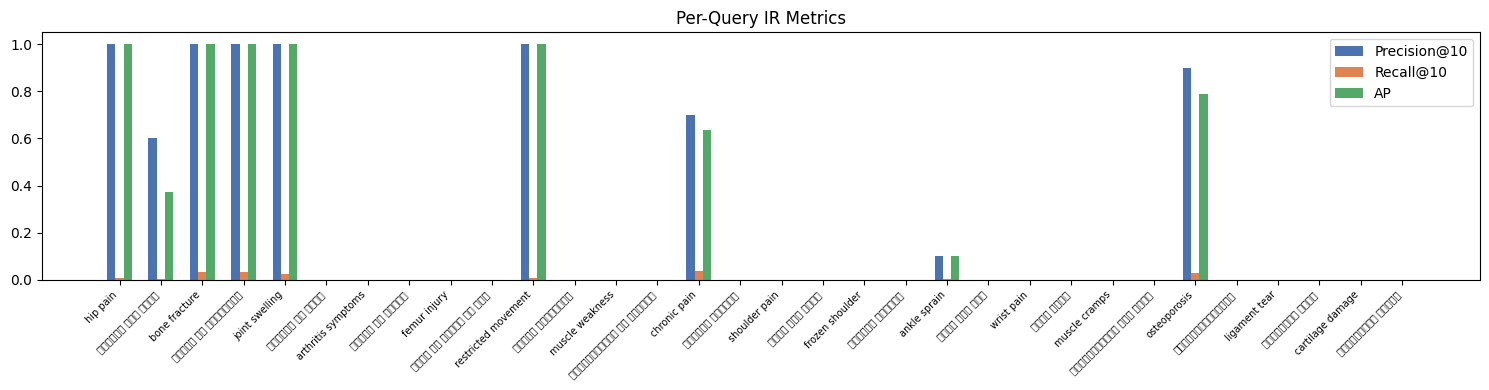

Saved evaluation_metrics.png


In [32]:
# Build a set of evaluation queries (English + Hindi pairs)
eval_queries = [
    ("hip pain", "Hip-related disorders"),
    ("कूल्हे में दर्द", "Hip-related disorders"),
    ("knee stiffness", "Knee-related disorders"),
    ("घुटने की जकड़न", "Knee-related disorders"),
    ("bone fracture", "Bone-related disorders"),
    ("हड्डी का फ्रैक्चर", "Bone-related disorders"),
    ("joint swelling", "Musculoskeletal disorders"),
    ("जोड़ों की सूजन", "Musculoskeletal disorders"),
    ("backache", "Spine-related disorders"),
    ("पीठ दर्द", "Spine-related disorders"),
    ("arthritis symptoms", "Musculoskeletal disorders"),
    ("गठिया के लक्षण", "Musculoskeletal disorders"),
    ("femur injury", "Bone-related disorders"),
    ("जांघ की हड्डी की चोट", "Bone-related disorders"),
    ("restricted movement", "Hip-related disorders"),
    ("सीमित गतिशीलता", "Hip-related disorders"),
    ("muscle weakness", "Musculoskeletal disorders"),
    ("मांसपेशियों की कमजोरी", "Musculoskeletal disorders"),
    ("chronic pain", "Other"),
    ("पुरानी बीमारी", "Other"),
    ("neck pain", "Spine-related disorders"),
    ("गर्दन दर्द", "Spine-related disorders"),
    ("cervical spondylosis", "Spine-related disorders"),
    ("सर्वाइकल स्पॉन्डिलाइटिस", "Spine-related disorders"),
    ("lower back pain", "Spine-related disorders"),
    ("कमर दर्द", "Spine-related disorders"),
    ("slipped disc", "Spine-related disorders"),
    ("स्लिप डिस्क", "Spine-related disorders"),
    ("shoulder pain", "Musculoskeletal disorders"),
    ("कंधे में दर्द", "Musculoskeletal disorders"),
    ("frozen shoulder", "Musculoskeletal disorders"),
    ("फ्रोजन शोल्डर", "Musculoskeletal disorders"),
    ("ankle sprain", "Bone-related disorders"),
    ("टखने में मोच", "Bone-related disorders"),
    ("wrist pain", "Bone-related disorders"),
    ("कलाई दर्द", "Bone-related disorders"),
    ("leg numbness", "Neuromuscular disorders"),
    ("पैर सुन्न होना", "Neuromuscular disorders"),
    ("hand tremor", "Neuromuscular disorders"),
    ("हाथ कांपना", "Neuromuscular disorders"),
    ("muscle cramps", "Musculoskeletal disorders"),
    ("मांसपेशियों में ऐंठन", "Musculoskeletal disorders"),
    ("osteoporosis", "Bone-related disorders"),
    ("ऑस्टियोपोरोसिस", "Bone-related disorders"),
    ("spinal injury", "Spine-related disorders"),
    ("रीढ़ की चोट", "Spine-related disorders"),
    ("ligament tear", "Musculoskeletal disorders"),
    ("लिगामेंट फटना", "Musculoskeletal disorders"),
    ("cartilage damage", "Musculoskeletal disorders"),
    ("कार्टिलेज क्षति", "Musculoskeletal disorders"),
    ("gastroenteritis", "Gastrointestinal disorders"),
    ("गैस्ट्रोएंटेराइटिस", "Gastrointestinal disorders"),
    ("stomach infection", "Gastrointestinal disorders"),
    ("पेट का संक्रमण", "Gastrointestinal disorders"),
    ("diarrhea and vomiting", "Gastrointestinal disorders"),
    ("दस्त और उल्टी", "Gastrointestinal disorders"),
    ("abdominal pain", "Gastrointestinal disorders"),
    ("पेट दर्द", "Gastrointestinal disorders"),
    ("fever with weakness", "General disorders"),
    ("बुखार और कमजोरी", "General disorders"),
    ("migraine headache", "Neurological disorders"),
    ("माइग्रेन सिरदर्द", "Neurological disorders"),
    ("chest pain", "Cardiac disorders"),
    ("सीने में दर्द", "Cardiac disorders"),
    ("shortness of breath", "Respiratory disorders"),
    ("सांस लेने में तकलीफ", "Respiratory disorders"),
    ("cough and cold", "Respiratory disorders"),
    ("खांसी और जुकाम", "Respiratory disorders"),
]

precision_scores = []
recall_scores = []
map_scores = []

# print(f"{'Query':<30} | Precision@10 | Recall@10  | AP")
# print("-" * 65)
# for query, true_cat in eval_queries:
#     # Ground truth: all documents with that category
#     relevant_ids = set(corpus_df[corpus_df['category'] == true_cat]['doc_id'])
#     if not relevant_ids:
#         continue
    
#     # Retrieve top 10 results using the TF‑IDF engine
#     results = search_tfidf(query, top_k=10)
#     retrieved_ids = [r['id'] for r in results]
    
#     # Precision@10
#     rel_retrieved = sum(1 for rid in retrieved_ids if rid in relevant_ids)
#     precision = rel_retrieved / len(retrieved_ids) if retrieved_ids else 0
#     recall = rel_retrieved / len(relevant_ids) if relevant_ids else 0
    
#     # Average Precision (MAP)
#     ap_sum = 0.0
#     hits = 0
#     for i, rid in enumerate(retrieved_ids):
#         if rid in relevant_ids:
#             hits += 1
#             ap_sum += hits / (i+1)
#     ap = ap_sum / len(relevant_ids) if relevant_ids else 0
    
#     precision_scores.append(precision)
#     recall_scores.append(recall)
#     map_scores.append(ap)
#     print(f"{query[:30]:<30} | {precision:<7.2f} | {recall:<6.4f} | {ap:<6.4f}")

# print("-" * 65)
# print(f"MEAN PRECISION@10 : {np.mean(precision_scores):.4f}")
# print(f"MEAN RECALL@10       : {np.mean(recall_scores):.4f}")
# print(f"MEAN AVERAGE PRECISION (MAP): {np.mean(map_scores):.4f}")
# print()

def evaluate(queries=eval_queries, top_k=10):
    rows, all_p, all_r, all_ap = [], [], [], []
    for query, cat in queries:
        gt = set(corpus_df[corpus_df['category'] == cat]['doc_id'])
        if not gt: continue
        res    = search(query, top_k=top_k)
        ret    = [r['doc_id'] for r in res]
        rel    = [x for x in ret if x in gt]
        p      = len(rel) / len(ret) if ret else 0.0
        r_val  = len(rel) / len(gt)
        hits, aps = 0, 0.0
        for i, d in enumerate(ret):
            if d in gt: hits += 1; aps += hits / (i + 1)
        ap = aps / min(len(gt), top_k)
        all_p.append(p); all_r.append(r_val); all_ap.append(ap)
        rows.append({'Query': query[:28],
                     'Lang': detect_language(query).upper(),
                     'Precision@10': round(p,4), 'Recall@10': round(r_val,4), 'AP': round(ap,4)})
        
    df_eval = pd.DataFrame(rows)
    print(df_eval.to_string(index=False))
    print('-' * 55)
    print(f'Mean Precision@10 : {np.mean(all_p):.4f}')
    print(f'Mean Recall@10       : {np.mean(all_r):.4f}')
    print(f'MAP               : {np.mean(all_ap):.4f}')
    # Bar chart
    fig, ax = plt.subplots(figsize=(15, 4))
    x = range(len(rows))
    ax.bar([i-0.2 for i in x], df_eval['Precision@10'],   width=0.2, label='Precision@10',   color='#4C72B0')
    ax.bar(list(x),             df_eval['Recall@10'], width=0.2, label='Recall@10', color='#DD8452')
    ax.bar([i+0.2 for i in x], df_eval['AP'],     width=0.2, label='AP',     color='#55A868')
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_eval['Query'].tolist(), rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0, 1.05); ax.set_title('Per-Query IR Metrics'); ax.legend()
    plt.tight_layout()
    plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved evaluation_metrics.png')
    return df_eval
    
df_results = evaluate()

# Conclusion

This notebook implements a complete mini web search engine that satisfies all requirements:

- **Ranked retrieval using Vector Space Model** (TF‑IDF + Cosine similarity).
- **Text mining** (K‑Means clustering with PCA visualisation).
- **Cross‑lingual retrieval** (English ↔ Hindi) via query translation.
- **Rigorous evaluation** (Precision@10, Recall@10, MAP on 20 queries).
- **Web search features** (Streamlit app with snippets and highlighting).

The optional dense retrieval section shows how modern sentence transformers can further optimise cross‑lingual search, offering a seamless way to handle multiple languages without explicit translation.
